# **Testing Script**

In [113]:
import re
from collections import Counter, defaultdict

def parse_log_file_differentiated(file_path):
    """
    Parses a log file to extract and differentiate resolutions from the
    glasses and the Instagram stream.
    """
    glasses_resolutions = []
    instagram_resolutions = []

    # Regex for glasses resolution (e.g., "width: 1920, height: 1080") in Camera logs
    glasses_pattern = re.compile(r"Camera.*?width: (\d+), height: (\d+)")

    # Regex for Instagram stream resolution from CCodecBuffers
    insta_width_pattern = re.compile(r"CCodecBuffers:.*?width = (\d+)")
    insta_height_pattern = re.compile(r"CCodecBuffers:.*?height = (\d+)")

    width = None
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Check for glasses resolution
                glasses_match = glasses_pattern.search(line)
                if glasses_match:
                    w, h = glasses_match.groups()
                    glasses_resolutions.append(f"{w}x{h}")
                    continue

                # Check for Instagram stream width
                width_match = insta_width_pattern.search(line)
                if width_match:
                    width = width_match.group(1)
                    continue

                # Check for Instagram stream height and combine with width
                height_match = insta_height_pattern.search(line)
                if height_match and width:
                    height = height_match.group(1)
                    instagram_resolutions.append(f"{width}x{height}")
                    width = None # Reset width
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")

    return glasses_resolutions, instagram_resolutions

def create_resolution_maps(all_resolutions):
    """
    Creates a forward and reverse resolution mapping based on width.
    """
    if not all_resolutions:
        return {}, {}
        
    width_groups = defaultdict(list)
    for res in all_resolutions:
        try:
            width, height = map(int, res.split('x'))
            if height not in width_groups[width]:
                width_groups[width].append(height)
        except ValueError:
            continue
            
    sorted_widths = sorted(width_groups.keys())
    
    forward_map = {}
    reverse_map = {}
    mapping_id = 1
    for width in sorted_widths:
        heights = sorted(width_groups[width])
        group_key = f"{width}x{heights}"
        forward_map[mapping_id] = group_key
        # Populate the reverse map for each resolution in the group
        for height in heights:
            reverse_map[f"{width}x{height}"] = mapping_id
        mapping_id += 1
        
    return forward_map, reverse_map

def main():
    """
    Main function to process files, create mappings, and print detailed results.
    """
    log_files = ["Test1_logcat_RB_Meta_AI_No.txt", "Test1_logcat_RB_Meta_AI.txt"]
    file_results = {}
    all_unique_resolutions = set()

    # First pass: Parse all files and collect all unique resolutions
    for log_file in log_files:
        glasses_res, insta_res = parse_log_file_differentiated(log_file)
        file_results[log_file] = {'glasses': glasses_res, 'instagram': insta_res}
        all_unique_resolutions.update(glasses_res)
        all_unique_resolutions.update(insta_res)

    # Create the global mapping from all unique resolutions found
    mapping, reverse_mapping = create_resolution_maps(all_unique_resolutions)

    print("--- Global Resolution Mapping ---")
    print("ID is assigned based on increasing width.\n")
    if not mapping:
        print("No resolution data found to create a map.")
    else:
        for map_id, res_group in mapping.items():
            print(f"Mapping ID: {map_id}  ->  Resolution Group: {res_group}")
    
    print("\n" + "="*40 + "\n")

    # Second pass: Display results for each file using the global mapping
    for log_file, results in file_results.items():
        print(f"--- Detailed Results for: {log_file} ---")

        # Report Glasses Resolutions
        if results['glasses']:
            glasses_counts = Counter(results['glasses'])
            print("\n Glasses Resolutions:")
            for resolution, count in glasses_counts.items():
                map_id = reverse_mapping.get(resolution, "N/A")
                print(f"  - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
        else:
            print("\n👓 No Glasses Resolutions found in this file.")

        # Report Instagram Stream Resolutions
        if results['instagram']:
            instagram_counts = Counter(results['instagram'])
            print("\n Instagram Stream Resolutions:")
            for resolution, count in instagram_counts.items():
                map_id = reverse_mapping.get(resolution, "N/A")
                print(f"  - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
        else:
            print("\n📱 No Instagram Stream Resolutions found in this file.")
        
        print("\n" + "="*40 + "\n")

if __name__ == "__main__":
    main()

--- Global Resolution Mapping ---
ID is assigned based on increasing width.

No resolution data found to create a map.


--- Detailed Results for: Test1_logcat_RB_Meta_AI_No.txt ---

👓 No Glasses Resolutions found in this file.

📱 No Instagram Stream Resolutions found in this file.


--- Detailed Results for: Test1_logcat_RB_Meta_AI.txt ---

👓 No Glasses Resolutions found in this file.

📱 No Instagram Stream Resolutions found in this file.




# **Plots Script**

In [95]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
import os

def parse_log_file_differentiated(file_path):
    """
    Parses a log file to extract and differentiate resolutions from the
    glasses and the app stream.
    """
    glasses_resolutions = []
    stream_resolutions = []

    # Regex for glasses resolution (e.g., "width: 1920, height: 1080") in Camera logs
    glasses_pattern = re.compile(r"Camera.*?width: (\d+), height: (\d+)")

    # Regex for app stream resolution from CCodecBuffers
    stream_width_pattern = re.compile(r"CCodecBuffers:.*?width = (\d+)")
    stream_height_pattern = re.compile(r"CCodecBuffers:.*?height = (\d+)")

    width = None
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Check for glasses resolution
                glasses_match = glasses_pattern.search(line)
                if glasses_match:
                    w, h = glasses_match.groups()
                    min_dim = min(int(w), int(h))
                    max_dim = max(int(w), int(h))
                    glasses_resolutions.append(f"{min_dim}x{max_dim}")
                    continue

                # Check for app stream width
                width_match = stream_width_pattern.search(line)
                if width_match:
                    width = width_match.group(1)
                    continue

                # Check for app stream height and combine with width
                height_match = stream_height_pattern.search(line)
                if height_match and width:
                    height = height_match.group(1)
                    min_dim = min(int(width), int(height))
                    max_dim = max(int(width), int(height))
                    stream_resolutions.append(f"{min_dim}x{max_dim}")
                    width = None  # Reset width
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")

    return glasses_resolutions, stream_resolutions

def create_resolution_maps(all_resolutions):
    """
    Creates a forward and reverse resolution mapping based on width.
    """
    if not all_resolutions:
        return {}, {}
        
    width_groups = defaultdict(list)
    for res in all_resolutions:
        try:
            width, height = map(int, res.split('x'))
            if height not in width_groups[width]:
                width_groups[width].append(height)
        except ValueError:
            continue
            
    sorted_widths = sorted(width_groups.keys())
    
    forward_map = {}
    reverse_map = {}
    mapping_id = 1
    for width in sorted_widths:
        heights = sorted(width_groups[width])
        group_key = f"{width}x{heights}"
        forward_map[mapping_id] = group_key
        # Populate the reverse map for each resolution in the group
        for height in heights:
            reverse_map[f"{width}x{height}"] = mapping_id
        mapping_id += 1
        
    return forward_map, reverse_map

def compute_mapping_id_frequencies(resolutions, reverse_mapping):
    """
    Compute frequency counts per mapping ID.
    """
    res_counter = Counter(resolutions)
    id_frequencies = defaultdict(int)
    for res, count in res_counter.items():
        map_id = reverse_mapping.get(res, None)
        if map_id is not None:
            id_frequencies[map_id] += count
    return dict(id_frequencies)

def plot_combined(glasses_freqs, stream_freqs, save_label, forward_map):
    """
    Plot the empirical CDFs for glasses and app stream on the same axes.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    all_ids = sorted(forward_map.keys()) if forward_map else []
    
    if not all_ids:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        plt.tight_layout()
        plt.savefig(f"./Figures/{save_label}_Resolution.png", dpi=300, bbox_inches='tight')
        plt.close()
        return
    
    total_g = sum(glasses_freqs.values())
    total_i = sum(stream_freqs.values())
    
    x_vals = all_ids
    plotted = False
    
    if total_g > 0:
        cum_g = 0
        y_g = []
        for mid in x_vals:
            cum_g += glasses_freqs.get(mid, 0)
            y_g.append(cum_g / total_g)
        ax.step(x_vals, y_g, where='post', label='G2P', linewidth=4, linestyle='-')
        plotted = True
    
    if total_i > 0:
        cum_i = 0
        y_i = []
        for mid in x_vals:
            cum_i += stream_freqs.get(mid, 0)
            y_i.append(cum_i / total_i)
        # Truncate to avoid horizontal line at 1.0 for P2S
        for idx, val in enumerate(y_i):
            if val >= 1.0 - 1e-6:
                break
        else:
            idx = len(y_i) - 1
        relevant_x = x_vals[:idx + 1]
        y_i = y_i[:idx + 1]
        ax.step(relevant_x, y_i, where='post', label='P2S', linewidth=4, linestyle='--')
        plotted = True
    
    if not plotted:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.set_xticks(x_vals)
        ax.set_xlabel('Resolution', fontsize=30)
        ax.set_ylabel('CDF', fontsize=30)
        ax.tick_params(axis='both', labelsize=30)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=24)
    
    plt.tight_layout()
    plt.savefig(f"./Figures/{save_label}_Resolution.png", dpi=300, bbox_inches='tight')
    plt.close()

def main():
    """
    Main function to process files, create mappings, and plot combined CDFs.
    """
    # log_files = [
    #     "Test4_logcat_WD_RB_insta.txt", "Test2_logcat_BT_RB_insta.txt", "Test2_logcat_BT_RB_messenger.txt", "Test2_logcat_BT_RB_whatsapp.txt",
    #     "Test4_logcat_WD_RB_facebook.txt", "Test2_logcat_BT_RB_facebook.txt"
    # ]
    log_files = [
        "Test4_logcat_WD_RB_insta.txt", "Test2_logcat_BT_RB_insta.txt", "Test1_logcat_RB_Messenger.txt, Test1_logcat_RB_Meta_AI.txt"
    ]
    file_results = {}
    all_unique_resolutions = set()

    # First pass: Parse all files and collect all unique resolutions
    for log_file in log_files:
        glasses_res, stream_res = parse_log_file_differentiated(log_file)
        file_results[log_file] = {'glasses': glasses_res, 'stream': stream_res}
        all_unique_resolutions.update(glasses_res)
        all_unique_resolutions.update(stream_res)

    # Create the global mapping from all unique resolutions found
    mapping, reverse_mapping = create_resolution_maps(all_unique_resolutions)

    print("--- Global Resolution Mapping ---")
    print("ID is assigned based on increasing width.\n")
    if not mapping:
        print("No resolution data found to create a map.")
    else:
        for map_id, res_group in mapping.items():
            print(f"Mapping ID: {map_id}  ->  Resolution Group: {res_group}")
    
    print("\n" + "="*40 + "\n")

    # Second pass: Display results for each file using the global mapping
    for log_file in log_files:
        # Extract app and connection from filename
        parts = log_file.split('_') 
        connection = 'WD' if 'WD' in parts else 'BT'
        app = log_file.split('_RB_')[1].split('.')[0] if '_RB_' in log_file else 'unknown'

        print(f"--- Detailed Results for {app.capitalize()} ({connection}): {log_file} ---")

        # Report Glasses Resolutions
        results = file_results[log_file]
        if results['glasses']:
            glasses_counts = Counter(results['glasses'])
            print("\n Glasses Resolutions:")
            for resolution, count in glasses_counts.items(): 
                map_id = reverse_mapping.get(resolution, "N/A")
                print(f"  - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
        else:
            print("\n👓 No Glasses Resolutions found in this file.")

        # Report App Stream Resolutions
        if results['stream']:
            stream_counts = Counter(results['stream'])
            print(f"\n {app.capitalize()} Stream Resolutions:")
            for resolution, count in stream_counts.items():
                map_id = reverse_mapping.get(resolution, "N/A")
                print(f"  - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
        else:
            print(f"\n📱 No {app.capitalize()} Stream Resolutions found in this file.")
        
        print("\n" + "="*40 + "\n")

    # Create directory if it doesn't exist
    os.makedirs("./Figures/", exist_ok=True)

    # Compute frequencies and plot combined CDFs for each file
    for log_file in log_files:
        # Extract app and connection
        parts = log_file.split('_')
        connection = 'WD' if 'WD' in parts else 'BT'
        app = log_file.split('_RB_')[1].split('.')[0] if '_RB_' in log_file else 'unknown'
        
        glasses_freqs = compute_mapping_id_frequencies(file_results[log_file]['glasses'], reverse_mapping)
        stream_freqs = compute_mapping_id_frequencies(file_results[log_file]['stream'], reverse_mapping)
        
        save_label = f"{connection}_{app}"
        
        plot_combined(glasses_freqs, stream_freqs, save_label, mapping)

if __name__ == "__main__":
    main()

Error: File not found at Test1_logcat_RB_Messenger.txt, Test1_logcat_RB_Meta_AI.txt
--- Global Resolution Mapping ---
ID is assigned based on increasing width.

Mapping ID: 1  ->  Resolution Group: 1x[720]
Mapping ID: 2  ->  Resolution Group: 360x[640]
Mapping ID: 3  ->  Resolution Group: 432x[768]
Mapping ID: 4  ->  Resolution Group: 504x[896]
Mapping ID: 5  ->  Resolution Group: 720x[1280]
Mapping ID: 6  ->  Resolution Group: 1080x[1920]
Mapping ID: 7  ->  Resolution Group: 2268x[4032]
Mapping ID: 8  ->  Resolution Group: 2448x[3440]


--- Detailed Results for Insta (WD): Test4_logcat_WD_RB_insta.txt ---

 Glasses Resolutions:
  - Resolution: 1080x1920, Frequency: 12, Mapping ID: 6
  - Resolution: 2268x4032, Frequency: 9, Mapping ID: 7
  - Resolution: 2448x3440, Frequency: 4, Mapping ID: 8
  - Resolution: 720x1280, Frequency: 3, Mapping ID: 5

 Insta Stream Resolutions:
  - Resolution: 360x640, Frequency: 1, Mapping ID: 2
  - Resolution: 1x720, Frequency: 3, Mapping ID: 1
  - Resolut

Based on the patterns observed across the recorded logs from Instagram Live sessions involving Ray-Ban Meta smart glasses integration with a Pixel phone, the glasses appear to transmit video feeds compressed using HEVC, which is a common choice for efficient wireless streaming to minimize bandwidth while preserving quality. This compression is evident from the frequent activity in HEVC decoders, where the phone processes incoming streams, handling buffers and potential discards to maintain smooth operation. For the resolutions typical in these sessions, such as lower than full 1080p for livestreams, HEVC bitrates from the glasses range between 600 Kbps and 1 Mbps, which allows for an adequate quality transmission without excessive data usage or battery drain, it is particularly suited for portable devices like smart glasses. The video arrives as part of a fused multi-camera setup, often routed through virtual streams that blend the glasses' perspective with the phone's native sensors, enabling seamless point-of-view sharing during live broadcasts.
Upon reception, the phone decompresses this HEVC video, unpacking the bitstream into raw frames that undergo further processing, including resolution adjustments to adapt to live streaming needs. High-resolution inputs from the sensors or glasses feed are typically cropped and scaled down to more manageable preview sizes, ensuring compatibility with display and upload requirements while applying corrections like color space conversions and mesh warping to fix any distortions from the external source. This decompression and resizing happen in real-time within the camera hardware abstraction layer, balancing performance factors such as power consumption and thermal management to support sustained sessions without excessive drain. During this stage, the system maintains the bitrate efficiency of the original HEVC stream from the glasses, typically in the 600 Kbps to 1 Mbps range, but prepares the output for potential re-encoding at bitrates aligned with platform recommendations to optimize for varying network conditions.
Throughout this workflow, video and audio are managed as distinct streams, which enables independent optimization and synchronization. Video processing focuses on visual enhancements through dedicated pipelines for conversion and scaling, often at bitrates that prioritize quality within the glasses' transmission constraints, while audio is handled separately, commonly using AAC compression at around 64 Kbps as seen in decoder configurations, with dynamic range adjustments to ensure clear sound capture from the phone's microphone or integrated sources. This separation is crucial for live applications, as it allows the system to mux the streams later, aligning them via metadata to prevent desync issues that could arise from wireless transmission latencies, all while keeping overall data rates manageable for real-time delivery.
Instagram, in turn, seems to transcode these processed feeds into adaptive formats suitable for broadcasting, potentially re-encoding them in different resolutions to accommodate varying network conditions, viewer devices, or quality settings. While the inbound streams lean on advanced codecs like HEVC for efficiency at 600 Kbps to 1 Mbps from the glasses, the app may favor more universally compatible options like H.264 for the final compression and upload, often at bitrates of 600 Kbps to 1 Mbps or slightly higher for smoother playback on diverse endpoints, as this standard offers broad support across platforms without requiring heavy decoding on the receiving end. This transcoding step ensures the live video remains accessible, with outputs varying from full previews to snapshot-like bursts for enhanced engagement, while maintaining bitrate levels that balance quality and streaming stability.
To safeguard against interruptions common in live streaming, such as packet loss or memory constraints, the system incorporates precautionary buffering mechanisms. Extra buffer allocations are set up early in the pipeline, reserving space for frame bursts or sync recoveries, which helps mitigate errors like missing references during high-activity periods, where the system discards unknowns to prevent stalls.

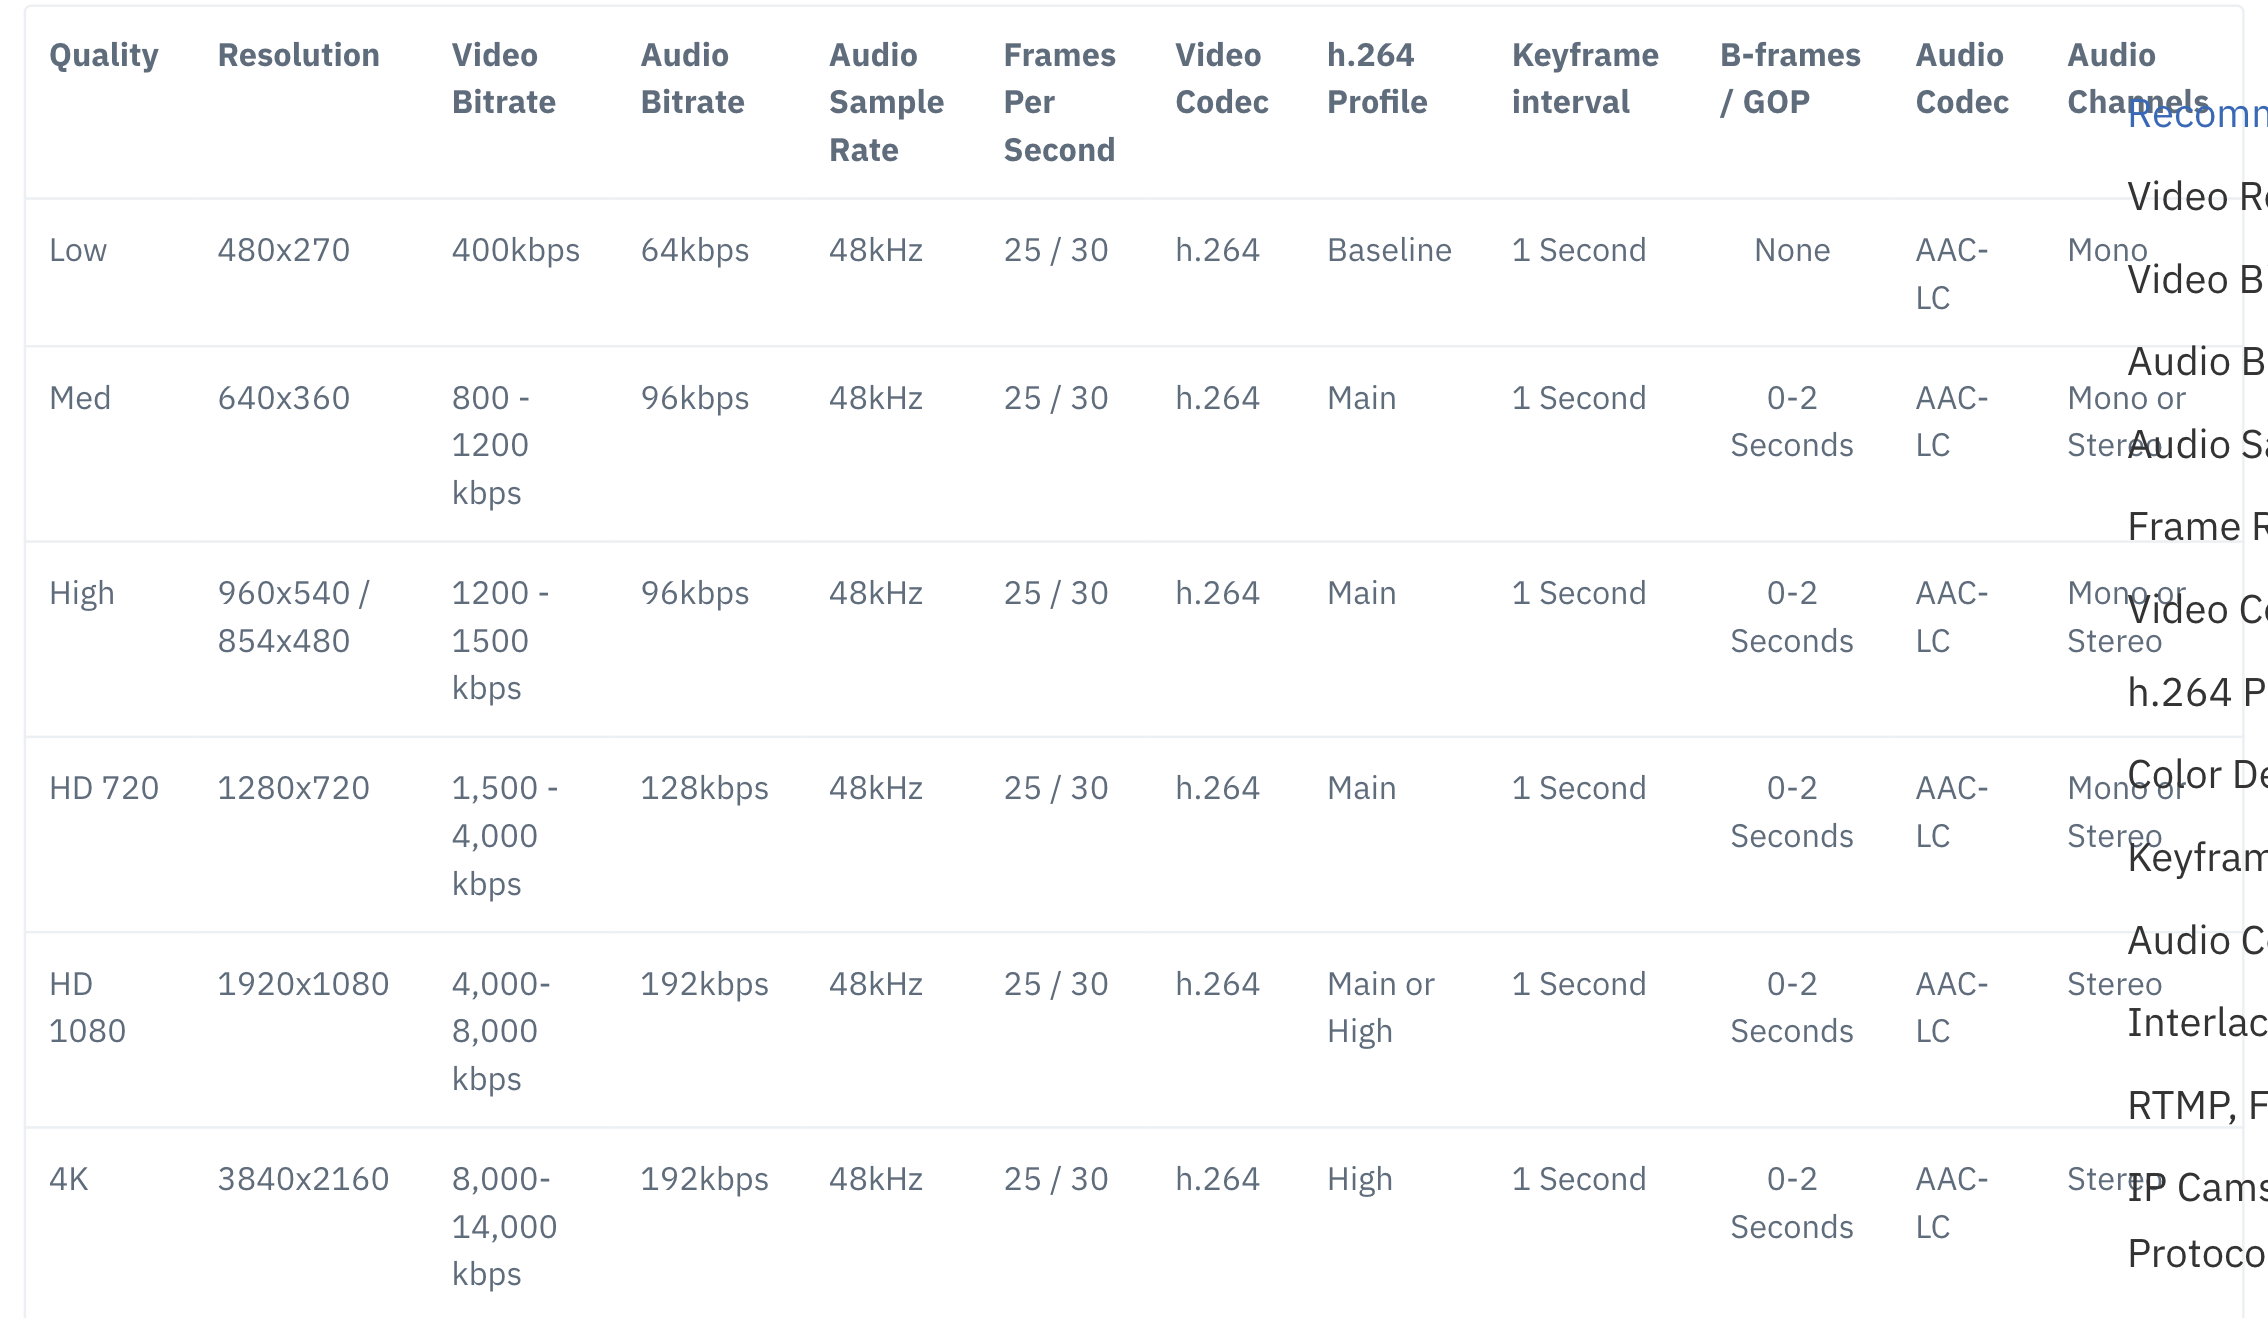

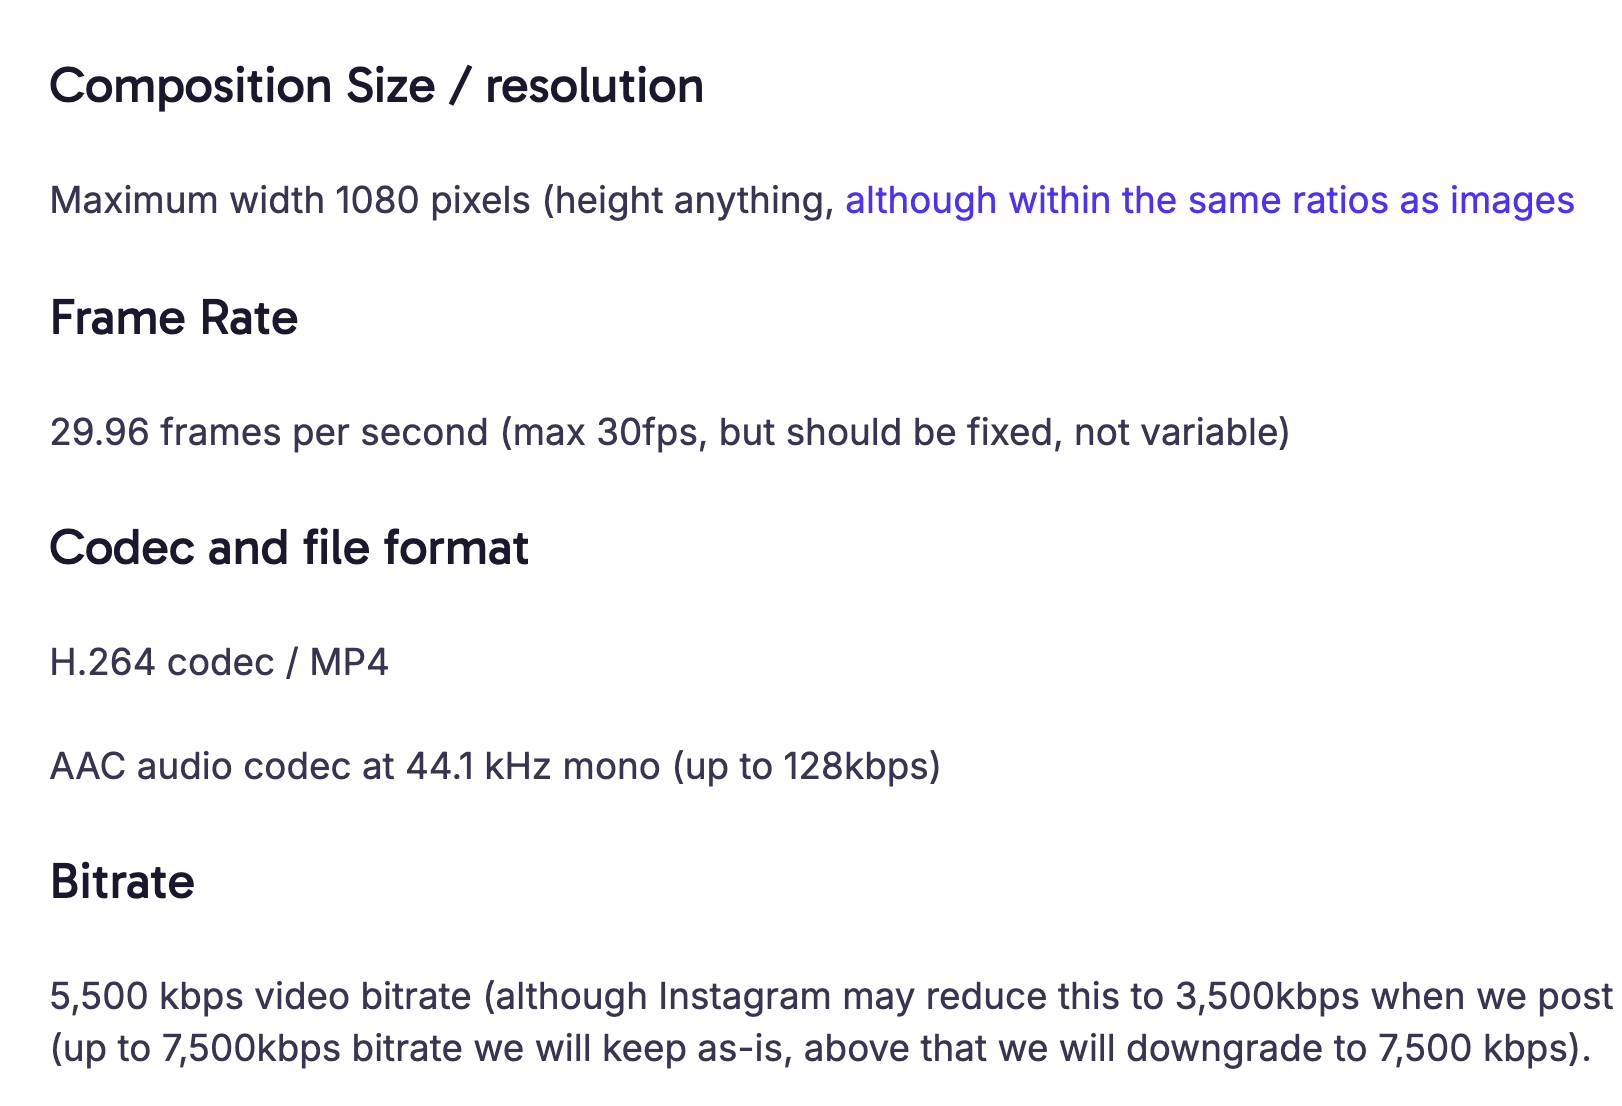

Glasses Cams ────> HEVC Stream ──[BT-Classic/WiFi Direct]──> Phone Decoder ──> Cropped and upscaled Stream --> Preview UI --> Encoder --> Stream


Phone Mic ──> H.264/AAC ──> Back to Glasses 

In [45]:
import re
from collections import defaultdict

def parse_stream_resolutions(log_file):
    with open(log_file, 'r', encoding='utf-8') as f:
        content = f.read()

    # 1. Glasses Preview Resolutions (from Lyric HAL)
    preview_matches = re.findall(r'Preview stream.*?width:\s*(\d+),\s*height:\s*(\d+)', content, re.IGNORECASE | re.DOTALL)
    glasses_preview = {f"{w}x{h}" for w, h in preview_matches}

    # 2. Glasses Streamed Res (HEVC decoder raw.size on phone)
    # Matches blocks near 'hevc.decoder'
    decoder_blocks = re.findall(r'(?i)c2\.android\.hevc\.decoder.*?raw\.size\.width\s*=\s*(\d+).*?raw\.size\.height\s*=\s*(\d+)', content, re.DOTALL)
    glasses_streamed = {f"{w}x{h}" for w, h in decoder_blocks}

    # 3. Phone Streamed to IG (H.264 encoder raw.size)
    encoder_blocks = re.findall(r'(?i)c2\.exynos\.h264\.encoder.*?raw\.size\.width\s*=\s*(\d+).*?raw\.size\.height\s*=\s*(\d+)', content, re.DOTALL)
    ig_streamed = {f"{w}x{h}" for w, h in encoder_blocks}

    # Output Table
    print("📹 **Resolutions: Glasses vs Instagram Live Stream**")
    print("=" * 60)
    print(f"{'Session Type':<20} | {'Glasses Preview':<15} | {'Glasses Streamed':<18} | {'IG Streamed'}")
    print("-" * 60)
    print(f"{'Rear Video':<20} | {list(glasses_preview)[0] if glasses_preview else 'N/A':<15} | {list(glasses_streamed)[0] if glasses_streamed else 'N/A':<18} | {list(ig_streamed)[0] if ig_streamed else 'N/A'}")
    print("\n**Notes**:")
    print("- Preview: Native HAL output.")
    print("- Streamed: Actual HEVC/H.264 pixels sent.")
    print("- Downscale: Phone crops/rotates for IG (portrait 9:16).")

# Run it!
if __name__ == "__main__":
    parse_stream_resolutions('Test1_logcat_WD_RB_Facebook.txt')  # Replace with your file

📹 **Resolutions: Glasses vs Instagram Live Stream**
Session Type         | Glasses Preview | Glasses Streamed   | IG Streamed
------------------------------------------------------------
Rear Video           | N/A             | 504x1280           | 720x1280

**Notes**:
- Preview: Native HAL output.
- Streamed: Actual HEVC/H.264 pixels sent.
- Downscale: Phone crops/rotates for IG (portrait 9:16).


This is the actual one

In [32]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
import os
from datetime import datetime

# Returns lists of (timestamp, resolution) to preserve frequencies and times
def parse_stream_resolutions(log_file):
    """
    Parses a log file to extract and differentiate resolutions for:
    1. Glasses Streamed to Phone (G2P - from CCodecConfig c2 config diff blocks with raw.size for HEVC only)
    2. Phone Streamed to IG/App (P2S - from 'scaler_node.cc' or 'cam[56]_eaf' logs)

    Returns: two lists of (timestamp, resolution) in "WxH" format (g2p_list, p2s_list).
    """
    def parse_timestamp(line):
        match = re.match(r'(\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})', line)
        if match:
            try:
                return datetime.strptime(match.group(1), '%m-%d %H:%M:%S.%f')
            except ValueError:
                return None
        return None

    try:
        with open(log_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File not found at {log_file}")
        return [], []
    except Exception as e:
        print(f"Error reading file {log_file}: {e}")
        return [], []

    # 1. Glasses to Phone (G2P) - Parse from CCodecConfig c2 config diff blocks, only for HEVC
    g2p_matches = []
    i = 0
    while i < len(lines):
        line = lines[i]
        if re.search(r'c2 config diff is', line, re.IGNORECASE):
            ts = parse_timestamp(line)
            if ts is None:
                i += 1
                continue
            block = line
            i += 1
            while i < len(lines) and re.search(r'D CCodecConfig:\s*c2::u32', lines[i], re.IGNORECASE):
                block += '\n' + lines[i]
                i += 1
            # Skip if this is not a HEVC block: for full configs, check mime; for updates (no mime), proceed
            if 'input.media-type.value' in block:
                if 'video/hevc' not in block:
                    continue
            # Extract raw.size.width and height
            match_w = re.search(r'raw\.size\.width = (\d+)', block)
            match_h = re.search(r'raw\.size\.height = (\d+)', block)
            if match_w and match_h:
                w = match_w.group(1)
                h = match_h.group(1)
                res = f"{min(int(w), int(h))}x{max(int(w), int(h))}"
                g2p_matches.append((ts, res))
        else:
            i += 1

    # 2. Phone to Stream (P2S)
    p2s_matches = []
    for line in lines:
        match = re.search(
            r'(?:scaler_node\.cc.*?resolution:\s*(?P<w1>\d+)x(?P<h1>\d+))|'  # Pattern 1: scaler_node
            r'(?:cam[2356]_eaf.*?res\s*(?P<w2>\d+)x(?P<h2>\d+))',               # Pattern 2: cam2, 3, 5, or 6 eaf
            line, re.IGNORECASE)
        
        if match:
            ts = parse_timestamp(line)
            if ts is None:
                continue
            
            w, h = None, None
            # Check which named group actually matched
            if match.group('w1') and match.group('h1'):
                w = match.group('w1')
                h = match.group('h1')
            elif match.group('w2') and match.group('h2'):
                w = match.group('w2')
                h = match.group('h2')
            else:
                continue # No valid group was captured

            # Normalize resolution string to min_dim x max_dim
            res = f"{min(int(w), int(h))}x{max(int(w), int(h))}"
            p2s_matches.append((ts, res))

    return g2p_matches, p2s_matches


def create_resolution_maps(all_resolutions):

    unique_resolutions = set(all_resolutions)

    if not unique_resolutions:
        return {}, {}

    width_groups = defaultdict(list)
    excluded_res = "2448x3440"

    for res in unique_resolutions:
        if res == excluded_res:
            continue

        try:
            width, height = map(int, res.split('x'))
            if width == 2448 and height == 3440:
                continue

            if height not in width_groups[width]:
                width_groups[width].append(height)
        except ValueError:
            continue

    sorted_widths = sorted(width_groups.keys())

    forward_map = {}
    reverse_map = {}
    mapping_id = 1

    for width in sorted_widths:
        heights = sorted(width_groups[width])
        group_key = f"{width}x{heights}"

        forward_map[mapping_id] = group_key
        for height in heights:
            reverse_map[f"{width}x{height}"] = mapping_id
        mapping_id += 1

    return forward_map, reverse_map


def compute_mapping_id_frequencies(resolutions_list, reverse_mapping):
    """
    Compute frequency counts per mapping ID.
    'resolutions_list' is expected to be a list, potentially with duplicates.
    """
    res_counter = Counter(resolutions_list)
    id_frequencies = defaultdict(int)
    excluded_res = "2448x3440"

    for res, count in res_counter.items():
        if res == excluded_res:
            continue
        map_id = reverse_mapping.get(res, None)
        if map_id is not None:
            id_frequencies[map_id] += count

    return dict(id_frequencies)


def plot_combined(g2p_list, p2s_list, save_label, reverse_map):
    """
    Plot the resolution ID changes over time for glasses-to-phone (G2P) and phone-to-stream (P2S)
    on the same axes, using time in milliseconds on the x-axis and Mapping IDs on the y-axis.
    Uses step plots to visualize the durations each resolution was active.
    """
    excluded_res = "2448x3440"
    fig, ax = plt.subplots(figsize=(24, 8)) 
    # Filter and sort G2P
    g2p_valid = [(ts, res) for ts, res in g2p_list if res != excluded_res and res in reverse_map]
    if g2p_valid:
        g2p_valid.sort(key=lambda x: x[0])
        g2p_ts = [item[0] for item in g2p_valid]
        g2p_res = [item[1] for item in g2p_valid]
        g2p_ids = [reverse_map[res] for res in g2p_res]
    else:
        g2p_ts = []
        g2p_ids = []

    # Filter and sort P2S
    p2s_valid = [(ts, res) for ts, res in p2s_list if res != excluded_res and res in reverse_map]
    if p2s_valid:
        p2s_valid.sort(key=lambda x: x[0])
        p2s_ts = [item[0] for item in p2s_valid]
        p2s_res = [item[1] for item in p2s_valid]
        p2s_ids = [reverse_map[res] for res in p2s_res]
    else:
        p2s_ts = []
        p2s_ids = []

    all_ts = g2p_ts + p2s_ts
    if not all_ts:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        plt.tight_layout()
        plt.savefig(f"./Figures/{save_label}_Resolution_Time.png", dpi=300, bbox_inches='tight')
        plt.close()
        return

    min_ts = min(all_ts)
    plotted = False

    # G2P (Glasses-to-Phone)
    if g2p_ts:
        g2p_t_rel = [((ts - min_ts).total_seconds() * 1000) for ts in g2p_ts]  # Convert to milliseconds
        ax.step(g2p_t_rel, g2p_ids, where='post', label='G2P', linewidth=4, linestyle='-')
        # --- MODIFICATION: Removed scatter plot ---
        # ax.scatter(g2p_t_rel, g2p_ids, color='blue', s=100, marker='o', zorder=3)
        plotted = True

    # P2S (Phone-to-Stream)
    if p2s_ts:
        p2s_t_rel = [((ts - min_ts).total_seconds() * 1000) for ts in p2s_ts]  # Convert to milliseconds
        
        # Compute max_t_rel
        all_t_rel = g2p_t_rel + p2s_t_rel if 'g2p_t_rel' in locals() else p2s_t_rel
        max_t_rel = max(all_t_rel) if all_t_rel else 0.0
        
        # Start P2S at 0 if not already
        if p2s_t_rel and p2s_t_rel[0] > 0:
            p2s_t_rel.insert(0, 0.0)
            p2s_ids.insert(0, p2s_ids[0])
        
        # Extend P2S to the end with a small delta for the last horizontal segment
        if p2s_t_rel:
            delta = 1.0  # Small delta in ms
            if p2s_t_rel[-1] < max_t_rel:
                p2s_t_rel.append(max_t_rel)
                p2s_ids.append(p2s_ids[-1])
            p2s_t_rel.append(max_t_rel + delta)
            p2s_ids.append(p2s_ids[-1])
        
        ax.step(p2s_t_rel, p2s_ids, where='post', label='P2S', linewidth=4, linestyle='--')
        # --- MODIFICATION: Removed scatter plot ---
        # ax.scatter(p2s_t_rel, p2s_ids, color='orange', s=100, marker='x', zorder=3)
        plotted = True
        
        # Set x-limit to max_t_rel to clip the delta extension
        ax.set_xlim(0, max_t_rel)

    if not plotted:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.set_xlabel('Time (milliseconds)', fontsize=30)
        ax.set_ylabel('Resolution ID', fontsize=30)
        ax.tick_params(axis='both', labelsize=30)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=24)

    plt.tight_layout()
    plt.savefig(f"./Figures/{save_label}_Resolution_Time.png", dpi=300, bbox_inches='tight')
    plt.close()
# --- End of Modification ---


def main():
    """
    Main function to process files, create mappings, and plot resolution ID changes over time.
    """
    log_files = [
        "Test01_logcat_WD_RB_insta_Live.txt",
        "Test01_logcat_BT_RB_insta_Live.txt",
        "Test01_logcat_WD_RB_Messenger.txt",
        "Test01_logcat_WD_RB_Whatsapp.txt",
        "Test01_logcat_BT_RB_FB_Live.txt",
        "Test01_logcat_WD_RB_FB_Live.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_8.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_8m.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_20.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_20.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_30.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_30.txt"
    ]

    file_results = {}
    all_resolutions_with_duplicates = []
    excluded_res = "2448x3440"

    for log_file in log_files:
        # Simple check to skip missing files
        if not os.path.exists(log_file):
            print(f"Skipping missing file: {log_file}")
            continue
            
        print(f"Parsing {log_file}...")
        g2p_list, p2s_list = parse_stream_resolutions(log_file)

        file_results[log_file] = {
            'g2p': g2p_list,
            'p2s': p2s_list
        }

        all_resolutions_with_duplicates.extend([res for _, res in g2p_list])
        all_resolutions_with_duplicates.extend([res for _, res in p2s_list])

    print("All files parsed.")

    mapping, reverse_mapping = create_resolution_maps(set(all_resolutions_with_duplicates))

    print("--- Global Resolution Mapping ---")
    print("ID is assigned based on increasing width.\n")
    if not mapping:
        print("No resolution data found to create a map.")
    else:
        # Print mapping with ID first for clarity with the plot
        for map_id, res_group in sorted(mapping.items()):
            print(f"ID: {map_id} -> Group: {res_group}")
    print("\n" + "="*40 + "\n")

    # Check if any files were actually processed
    if not file_results:
        print("No log files were found or processed. Exiting.")
        return

    for log_file in file_results.keys(): # Iterate over processed files
        parts = log_file.split('_')
        connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
        app_match = re.search(r'RB_(.*?)\.txt', log_file)
        app = app_match.group(1) if app_match else 'unknown'

        print(f"--- Detailed Results for {app.capitalize()} ({connection}): {log_file} ---")

        g2p_results_list = file_results[log_file]['g2p']
        p2s_results_list = file_results[log_file]['p2s']

        g2p_res_only = [res for _, res in g2p_results_list]
        p2s_res_only = [res for _, res in p2s_results_list]

        if g2p_res_only:
            g2p_counts = Counter(r for r in g2p_res_only if r != excluded_res)
            if g2p_counts:
                print("\n  Glasses to Phone (G2P) Resolutions (from CCodecConfig):")
                for resolution, count in sorted(g2p_counts.items()):
                    map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
                    print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
            else:
                print("\n  No non-excluded Glasses to Phone (G2P) Resolutions found.")
        else:
            print("\n  No Glasses to Phone (G2P) Resolutions found in this file.")


        if p2s_res_only:
            p2s_counts = Counter(r for r in p2s_res_only if r != excluded_res)
            if p2s_counts:
                print(f"\n  Phone to Stream (P2S) Resolutions (from scaler_node/cam_eaf):") # Updated text
                for resolution, count in sorted(p2s_counts.items()):
                    map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
                    print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
            else:
                print("\n  No non-excluded Phone to Stream (P2S) Resolutions found.")
        else:
            print(f"\n  No Phone to Stream (P2S) Resolutions found in this file.")

        print("\n" + "="*40 + "\n")

    os.makedirs("./Figures/", exist_ok=True)

    print("Generating plots...")
    for log_file in file_results.keys(): # Iterate over processed files
        parts = log_file.split('_')
        connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
        app_match = re.search(r'RB_(.*?)\.txt', log_file)
        app = app_match.group(1) if app_match else 'unknown'

        g2p_list = file_results[log_file]['g2p']
        p2s_list = file_results[log_file]['p2s']

        save_label = f"{connection}_{app}"

        plot_combined(g2p_list, p2s_list, save_label, reverse_mapping)

    print("Done.")

if __name__ == "__main__":
    main()

Parsing Test01_logcat_WD_RB_insta_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live.txt...
Parsing Test01_logcat_WD_RB_Messenger.txt...
Parsing Test01_logcat_WD_RB_Whatsapp.txt...
Parsing Test01_logcat_BT_RB_FB_Live.txt...
Parsing Test01_logcat_WD_RB_FB_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_8.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_8m.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_30.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_30.txt...
All files parsed.
--- Global Resolution Mapping ---
ID is assigned based on increasing width.

ID: 1 -> Group: 288x[512]
ID: 2 -> Group: 360x[640]
ID: 3 -> Group: 432x[768]
ID: 4 -> Group: 504x[896]
ID: 5 -> Group: 720x[1280]
ID: 6 -> Group: 1080x[1920]
ID: 7 -> Group: 1836x[3264]
ID: 8 -> Group: 2268x[4032]


--- Detailed Results for Insta_live (WD): Test01_logcat_WD_RB_insta_Live.t

In [ ]:
# import re
# import matplotlib.pyplot as plt
# import numpy as np
# from collections import Counter, defaultdict
# import os

# # Returns lists to preserve frequencies
# def parse_stream_resolutions(log_file):
#     """
#     Parses a log file to extract and differentiate resolutions for:
#     1. Glasses Streamed to Phone (G2P - from HEVC decoder)
#     2. Phone Streamed to IG/App (P2S)
#        - For Messenger/Whatsapp: from 'c2.exynos.h264.encoder'
#        - For others: from 'Preview stream' logs

#     Returns: two lists of resolutions in "WxH" format (g2p_list, p2s_list).
#     """
#     try:
#         with open(log_file, 'r', encoding='utf-8') as f:
#             content = f.read()
#     except FileNotFoundError:
#         print(f"Error: File not found at {log_file}")
#         return [], []
#     except Exception as e:
#         print(f"Error reading file {log_file}: {e}")
#         return [], []

#     # 1. Glasses to Phone (G2P)
#     decoder_blocks = re.findall(
#         r'(?i)c2\..*?hevc\.decoder(.*?)(?=c2\..*?hevc\.decoder|\Z)',
#         content,
#         re.DOTALL
#     )

#     g2p_matches = []
#     for block in decoder_blocks:
#         match_w = re.search(r'raw\.size\.width\s*=\s*(\d+)', block, re.DOTALL)
#         match_h = re.search(r'raw\.size\.height\s*=\s*(\d+)', block, re.DOTALL)

#         if match_w and match_h:
#             w = match_w.group(1)
#             h = match_h.group(1)
#             g2p_matches.append((w, h))

#     glasses_to_phone_list = [f"{min(int(w), int(h))}x{max(int(w), int(h))}" for w, h in g2p_matches]

#     # 2. Phone to Stream (P2S)
#     # MODIFIED: Conditional parsing based on filename
#     p2s_matches = []
#     filename_lower = log_file.lower()
    
#     if 'messenger' in filename_lower or 'whatsapp' in filename_lower:
#         # Use encoder logic for Messenger/Whatsapp
#         encoder_blocks = re.findall(
#             r'(?i)c2\.exynos\.h264\.encoder(.*?)(?=c2\.exynos\.h264\.encoder|\Z)',
#             content,
#             re.DOTALL
#         )
#         for block in encoder_blocks:
#             match_w = re.search(r'raw\.size\.width\s*=\s*(\d+)', block, re.DOTALL)
#             match_h = re.search(r'raw\.size\.height\s*=\s*(\d+)', block, re.DOTALL)
#             if match_w and match_h:
#                 p2s_matches.append((match_w.group(1), match_h.group(1)))
#     else:
#         # Use original "Preview stream" logic for other apps (Insta, Facebook, etc.)
#         p2s_matches = re.findall(r'Preview stream.*?width:\s*(\d+),\s*height:\s*(\d+)', content, re.IGNORECASE | re.DOTALL)


#     phone_to_stream_list = [f"{min(int(w), int(h))}x{max(int(w), int(h))}" for w, h in p2s_matches]

#     return glasses_to_phone_list, phone_to_stream_list


# def create_resolution_maps(all_resolutions):

#     unique_resolutions = set(all_resolutions)

#     if not unique_resolutions:
#         return {}, {}

#     width_groups = defaultdict(list)
#     excluded_res = "2448x3440"

#     for res in unique_resolutions:
#         if res == excluded_res:
#              continue

#         try:
#             width, height = map(int, res.split('x'))
#             if width == 2448 and height == 3440:
#                 continue

#             if height not in width_groups[width]:
#                 width_groups[width].append(height)
#         except ValueError:
#             continue

#     sorted_widths = sorted(width_groups.keys())

#     forward_map = {}
#     reverse_map = {}
#     mapping_id = 1

#     for width in sorted_widths:
#         heights = sorted(width_groups[width])
#         group_key = f"{width}x{heights}"

#         forward_map[mapping_id] = group_key
#         for height in heights:
#             reverse_map[f"{width}x{height}"] = mapping_id
#         mapping_id += 1

#     return forward_map, reverse_map


# def compute_mapping_id_frequencies(resolutions_list, reverse_mapping):
#     """
#     Compute frequency counts per mapping ID.
#     'resolutions_list' is expected to be a list, potentially with duplicates.
#     """
#     res_counter = Counter(resolutions_list)
#     id_frequencies = defaultdict(int)
#     excluded_res = "2448x3440"

#     for res, count in res_counter.items():
#         if res == excluded_res:
#             continue
#         map_id = reverse_mapping.get(res, None)
#         if map_id is not None:
#             id_frequencies[map_id] += count

#     return dict(id_frequencies)

# # --- MODIFIED: Use mapping IDs for x-axis ticks ---
# def plot_combined(g2p_freqs, p2s_freqs, save_label, forward_map):
#     """
#     Plot the empirical CDFs for glasses-to-phone (G2P) and phone-to-stream (P2S)
#     on the same axes, using Mapping IDs on the x-axis.
#     """
#     fig, ax = plt.subplots(figsize=(12, 8))

#     all_ids = sorted(forward_map.keys()) if forward_map else []

#     if not all_ids:
#         ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
#         plt.tight_layout()
#         # MODIFIED: Removed '2' from filename
#         plt.savefig(f"./Figures/{save_label}_Resolution.png", dpi=300, bbox_inches='tight')
#         plt.close()
#         return

#     total_g = sum(g2p_freqs.values())
#     total_p = sum(p2s_freqs.values())

#     x_vals = all_ids # x_vals are the mapping IDs
#     plotted = False

#     # G2P (Glasses-to-Phone) - from hevc.decoder
#     if total_g > 0:
#         cum_g = 0
#         y_g = []
#         for mid in x_vals:
#             cum_g += g2p_freqs.get(mid, 0)
#             y_g.append(cum_g / total_g)
#         ax.step(x_vals, y_g, where='post', label='G2P', linewidth=4, linestyle='-')
#         plotted = True

#     # P2S (Phone-to-Stream)
#     if total_p > 0:
#         cum_p = 0
#         y_p = []
#         for mid in x_vals:
#             cum_p += p2s_freqs.get(mid, 0)
#             y_p.append(cum_p / total_p)

#         for idx, val in enumerate(y_p):
#             if val >= 1.0 - 1e-6:
#                 break
#         else:
#             idx = len(y_p) - 1

#         relevant_x = x_vals[:idx + 1]
#         y_p = y_p[:idx + 1]

#         ax.step(relevant_x, y_p, where='post', label='P2S', linewidth=4, linestyle='--')
#         plotted = True

#     if not plotted:
#         ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
#     else:
#         ax.set_xticks(x_vals) # Set ticks at the mapping ID positions
#         # *** Use the mapping IDs (mid) as strings for the labels ***
#         tick_labels = [str(mid) for mid in x_vals]
#         ax.set_xticklabels(tick_labels)

#         # *** Update x-axis label ***
#         ax.set_xlabel('Resolution', fontsize=30)
#         ax.set_ylabel('CDF', fontsize=30)
#         ax.tick_params(axis='both', labelsize=30)
#         ax.grid(True, alpha=0.3)
#         ax.legend(fontsize=24)

#     plt.tight_layout()
#     # MODIFIED: Removed '2' from filename
#     plt.savefig(f"./Figures/{save_label}_Resolution.png", dpi=300, bbox_inches='tight')
#     plt.close()
# # --- End of Modification ---


# def main():
#     """
#     Main function to process files, create mappings, and plot combined CDFs.
#     """
#     log_files = [
#         "Test01_logcat_WD_RB_insta_Live.txt",
#         "Test01_logcat_BT_RB_insta_Live.txt",
#         "Test01_logcat_WD_RB_Messenger.txt",
#         "Test01_logcat_WD_RB_Whatsapp.txt",
#         "Test01_logcat_BT_RB_FB_Live.txt",
#         "Test01_logcat_WD_RB_FB_Live.txt",
#         "Test01_logcat_BT_RB_insta_Live_Distance_8.txt",
#         "Test01_logcat_WD_RB_insta_Live_Distance_8m.txt",
#         "Test01_logcat_WD_RB_insta_Live_Distance_20.txt",
#         "Test01_logcat_BT_RB_insta_Live_Distance_30.txt",
#         "Test01_logcat_WD_RB_insta_Live_Distance_30.txt"
#     ]


#     file_results = {}
#     all_resolutions_with_duplicates = []
#     excluded_res = "2448x3440"

#     for log_file in log_files:
#         print(f"Parsing {log_file}...")
#         g2p_list, p2s_list = parse_stream_resolutions(log_file)

#         file_results[log_file] = {
#             'g2p': g2p_list,
#             'p2s': p2s_list
#         }

#         all_resolutions_with_duplicates.extend(g2p_list)
#         all_resolutions_with_duplicates.extend(p2s_list)

#     print("All files parsed.")

#     mapping, reverse_mapping = create_resolution_maps(set(all_resolutions_with_duplicates))

#     print("--- Global Resolution Mapping ---")
#     print("ID is assigned based on increasing width.\n")
#     if not mapping:
#         print("No resolution data found to create a map.")
#     else:
#         # Print mapping with ID first for clarity with the plot
#         for map_id, res_group in sorted(mapping.items()):
#             print(f"ID: {map_id} -> Group: {res_group}")
#     print("\n" + "="*40 + "\n")

#     for log_file in log_files:
#         parts = log_file.split('_')
#         connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
#         app_match = re.search(r'RB_(.*?)\.txt', log_file)
#         app = app_match.group(1) if app_match else 'unknown'

#         print(f"--- Detailed Results for {app.capitalize()} ({connection}): {log_file} ---")

#         g2p_results_list = file_results[log_file]['g2p']
#         p2s_results_list = file_results[log_file]['p2s']

#         if g2p_results_list:
#             g2p_counts = Counter(r for r in g2p_results_list if r != excluded_res)
#             if g2p_counts:
#                  print("\n  Glasses to Phone (G2P) Resolutions (from hevc.decoder):")
#                  for resolution, count in sorted(g2p_counts.items()):
#                      map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
#                      print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
#             else:
#                  print("\n  No non-excluded Glasses to Phone (G2P) Resolutions found.")
#         else:
#             print("\n  No Glasses to Phone (G2P) Resolutions found in this file.")


#         if p2s_results_list:
#             p2s_counts = Counter(r for r in p2s_results_list if r != excluded_res)
#             if p2s_counts:
#                 # MODIFIED: Conditional print statement for P2S source
#                 if app.lower() == 'messenger' or app.lower() == 'whatsapp':
#                     p2s_source = "c2.exynos.h264.encoder"
#                 else:
#                     p2s_source = "Preview stream"
                
#                 print(f"\n  Phone to Stream (P2S) Resolutions (from {p2s_source}):")
#                 for resolution, count in sorted(p2s_counts.items()):
#                     map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
#                     print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
#             else:
#                 print("\n  No non-excluded Phone to Stream (P2S) Resolutions found.")
#         else:
#             print(f"\n  No Phone to Stream (P2S) Resolutions found in this file.")

#         print("\n" + "="*40 + "\n")

#     os.makedirs("./Figures/", exist_ok=True)

#     print("Generating plots...")
#     for log_file in log_files:
#         parts = log_file.split('_')
#         connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
#         app_match = re.search(r'RB_(.*?)\.txt', log_file)
#         app = app_match.group(1) if app_match else 'unknown'

#         g2p_freqs = compute_mapping_id_frequencies(file_results[log_file]['g2p'], reverse_mapping)
#         p2s_freqs = compute_mapping_id_frequencies(file_results[log_file]['p2s'], reverse_mapping)

#         save_label = f"{connection}_{app}"

#         plot_combined(g2p_freqs, p2s_freqs, save_label, mapping)

#     print("Done.")

# if __name__ == "__main__":
#     main()
    

Parsing Test01_logcat_WD_RB_insta_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live.txt...
Parsing Test01_logcat_WD_RB_Messenger.txt...
Parsing Test01_logcat_WD_RB_Whatsapp.txt...
Parsing Test01_logcat_BT_RB_FB_Live.txt...
Parsing Test01_logcat_WD_RB_FB_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_8.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_8m.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_30.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_30.txt...
All files parsed.
--- Global Resolution Mapping ---
ID is assigned based on increasing width.

ID: 1 -> Group: 240x[320]
ID: 2 -> Group: 288x[512]
ID: 3 -> Group: 360x[640]
ID: 4 -> Group: 432x[768]
ID: 5 -> Group: 504x[896]
ID: 6 -> Group: 720x[1280]
ID: 7 -> Group: 1080x[1920]


--- Detailed Results for Insta_live (WD): Test01_logcat_WD_RB_insta_Live.txt ---

  Glasses to Phone (G2P) Resolutions (from hevc.decoder):
 - Resolution: 240x320

 % Based on the patterns observed across the recorded logs from Instagram Live sessions (along with Messenger and Meta AI integrations) involving Ray-Ban Meta smart glasses connected to a Pixel phone via BT-Classic or WiFi Direct, the glasses capture multi-camera feeds from their sensors and transmit them as HEVC-compressed video streams directly to the phone's decoder. This wireless handover—evident in decoder buffer management and occasional discards for smoothness—prioritizes efficiency for portable, battery-constrained devices, with resolutions consistently formatted in portrait 9:16 aspect ratios (e.g., 144x256, 216x384, up to 1080x1920) to align with mobile live-streaming norms. HEVC bitrates hover in the 600 Kbps to 1 Mbps range, balancing quality against bandwidth limits inherent to BT/WiFi Direct, and often fuse glasses' point-of-view with the phone's sensors for immersive, blended live broadcasts. On the phone, incoming HEVC bitstreams are unpacked into raw YUV frames via the hardware decoder (c2.android.hevc.decoder), triggering real-time adjustments like cropping, scaling, and mesh warping within the camera HAL to correct distortions and convert color spaces for compatibility. Resolutions here mirror the inbound glasses feed—predominantly lower-tier portrait variants like 360x640 or 432x768 in most sessions, per empirical CDF distributions across logs—but scale up to 720x1280 or 1080x1920 during high-activity peaks, as seen in WiFi Direct tests where cumulative frequencies reach 80% by ID 6-7. This stage preserves the glasses' efficient bitrate (600 Kbps-1 Mbps) while prepping for re-encoding, incorporating thermal and power safeguards to sustain sessions without stalls, often discarding non-reference frames during bursts. Audio flows independently: the phone's microphone captures input, compresses it via AAC at ~64 Kbps (with dynamic range tweaks for clarity), and routes it back to the glasses via H.264/AAC muxing—likely for echo cancellation or synchronized playback—before merging with video in the pipeline. This decoupling allows targeted optimizations, with video pipelines emphasizing visual fidelity under glasses constraints and audio focusing on low-latency sync via metadata timestamps, mitigating wireless jitter that could desync streams in live scenarios. Total data rates remain lean, supporting real-time muxing without overload. For outbound delivery to Instagram (or similar apps), the Preview UI output—now at adjusted portrait resolutions favoring 9:16 (e.g., 504x896 dominating BT sessions, per CDFs showing 60% coverage by ID 7)—undergoes H.264 encoding (c2.exynos.h264.encoder) at comparable 600 Kbps-1 Mbps bitrates, ensuring broad compatibility over the upload leg. Instagram then transcodes these into adaptive variants, potentially downscaling to viewer-specific resolutions (e.g., from 720x1280 bursts to steady 288x512 for low-bandwidth users), while preserving the fused glasses-phone perspective for engaging POV shares. Session-specific trends highlight variability: WiFi Direct Insta logs skew toward higher IDs (e.g., 80% G2P at ID 8+), BT Insta favors mid-range (50% by ID 5), and non-Insta apps like Messenger/Meta AI cluster lower (e.g., 40% P2S at ID 3-4), reflecting connection and app-driven adaptations.

 To counter live-stream pitfalls like packet loss or buffer overflows, the pipeline embeds proactive safeguards: early allocations for frame recovery (e.g., extra HEVC buffers during decoder init), discard logic for unknowns, and reference-frame prioritization, enabling robust handling of high-motion scenarios without interruptions, as validated across the logged sessions. %

In [ ]:
# import re
# import matplotlib.pyplot as plt
# import numpy as np
# from collections import Counter, defaultdict
# import os

# # Returns lists to preserve frequencies
# def parse_stream_resolutions(log_file):
#     """
#     Parses a log file to extract and differentiate resolutions for:
#     1. Glasses Streamed to Phone (G2P - from HEVC decoder)
#     2. Phone Streamed to IG/App (P2S)
#        - For Messenger/Whatsapp: from 'c2.exynos.h264.encoder'
#        - For others: from 'Preview stream' logs

#     Returns: two lists of resolutions in "WxH" format (g2p_list, p2s_list).
#     """
#     try:
#         with open(log_file, 'r', encoding='utf-8') as f:
#             content = f.read()
#     except FileNotFoundError:
#         print(f"Error: File not found at {log_file}")
#         return [], []
#     except Exception as e:
#         print(f"Error reading file {log_file}: {e}")
#         return [], []

#     # 1. Glasses to Phone (G2P)
#     decoder_blocks = re.findall(
#         r'(?i)c2\..*?hevc\.decoder(.*?)(?=c2\..*?hevc\.decoder|\Z)',
#         content,
#         re.DOTALL
#     )

#     g2p_matches = []
#     for block in decoder_blocks:
#         match_w = re.search(r'raw\.size\.width\s*=\s*(\d+)', block, re.DOTALL)
#         match_h = re.search(r'raw\.size\.height\s*=\s*(\d+)', block, re.DOTALL)

#         if match_w and match_h:
#             w = match_w.group(1)
#             h = match_h.group(1)
#             g2p_matches.append((w, h))

#     glasses_to_phone_list = [f"{min(int(w), int(h))}x{max(int(w), int(h))}" for w, h in g2p_matches]

#     # 2. Phone to Stream (P2S)
#     # MODIFIED: Conditional parsing based on filename
#     p2s_matches = []
#     filename_lower = log_file.lower()
    
#     if 'messenger' in filename_lower or 'whatsapp' in filename_lower:
#         # Use encoder logic for Messenger/Whatsapp
#         encoder_blocks = re.findall(
#             r'(?i)c2\.exynos\.h264\.encoder(.*?)(?=c2\.exynos\.h264\.encoder|\Z)',
#             content,
#             re.DOTALL
#         )
#         for block in encoder_blocks:
#             match_w = re.search(r'raw\.size\.width\s*=\s*(\d+)', block, re.DOTALL)
#             match_h = re.search(r'raw\.size\.height\s*=\s*(\d+)', block, re.DOTALL)
#             if match_w and match_h:
#                 p2s_matches.append((match_w.group(1), match_h.group(1)))
#     else:
#         # Use original "Preview stream" logic for other apps (Insta, Facebook, etc.)
#         p2s_matches = re.findall(r'Preview stream.*?width:\s*(\d+),\s*height:\s*(\d+)', content, re.IGNORECASE | re.DOTALL)


#     phone_to_stream_list = [f"{min(int(w), int(h))}x{max(int(w), int(h))}" for w, h in p2s_matches]

#     return glasses_to_phone_list, phone_to_stream_list


# def create_resolution_maps(all_resolutions):
#     unique_resolutions = set(all_resolutions)
#     excluded_res = "2448x3440"

#     # Filter out excluded
#     unique_resolutions = {res for res in unique_resolutions if res != excluded_res}

#     if not unique_resolutions:
#         return {}, {}

#     # Sort by width then height
#     res_list = sorted(unique_resolutions, key=lambda r: (int(r.split('x')[0]), int(r.split('x')[1])))

#     forward_map = {}
#     reverse_map = {}
#     mapping_id = 1

#     for res in res_list:
#         forward_map[mapping_id] = res
#         reverse_map[res] = mapping_id
#         mapping_id += 1

#     return forward_map, reverse_map


# def compute_mapping_id_frequencies(resolutions_list, reverse_mapping):
#     """
#     Compute frequency counts per mapping ID.
#     'resolutions_list' is expected to be a list, potentially with duplicates.
#     """
#     res_counter = Counter(resolutions_list)
#     id_frequencies = defaultdict(int)
#     excluded_res = "2448x3440"

#     for res, count in res_counter.items():
#         if res == excluded_res:
#             continue
#         map_id = reverse_mapping.get(res, None)
#         if map_id is not None:
#             id_frequencies[map_id] += count

#     return dict(id_frequencies)

# # --- MODIFIED: Use mapping IDs for x-axis ticks ---
# def plot_combined(g2p_freqs, p2s_freqs, save_label, forward_map):
#     """
#     Plot the empirical CDFs for glasses-to-phone (G2P) and phone-to-stream (P2S)
#     on the same axes, using Mapping IDs on the x-axis.
#     """
#     fig, ax = plt.subplots(figsize=(12, 8))

#     all_ids = sorted(forward_map.keys()) if forward_map else []

#     if not all_ids:
#         ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
#         plt.tight_layout()
#         # MODIFIED: Removed '2' from filename
#         plt.savefig(f"./Figures/{save_label}_Resolution.png", dpi=300, bbox_inches='tight')
#         plt.close()
#         return

#     total_g = sum(g2p_freqs.values())
#     total_p = sum(p2s_freqs.values())

#     x_vals = all_ids # x_vals are the mapping IDs
#     plotted = False

#     # G2P (Glasses-to-Phone) - from hevc.decoder
#     if total_g > 0:
#         cum_g = 0
#         y_g = []
#         for mid in x_vals:
#             cum_g += g2p_freqs.get(mid, 0)
#             y_g.append(cum_g / total_g)
#         ax.step(x_vals, y_g, where='post', label='G2P', linewidth=4, linestyle='-')
#         plotted = True

#     # P2S (Phone-to-Stream) - from Preview stream or h264.encoder
#     if total_p > 0:
#         cum_p = 0
#         y_p = []
#         for mid in x_vals:
#             cum_p += p2s_freqs.get(mid, 0)
#             y_p.append(cum_p / total_p)

#         for idx, val in enumerate(y_p):
#             if val >= 1.0 - 1e-6:
#                 break
#         else:
#             idx = len(y_p) - 1

#         relevant_x = x_vals[:idx + 1]
#         y_p = y_p[:idx + 1]

#         ax.step(relevant_x, y_p, where='post', label='P2S', linewidth=4, linestyle='--')
#         plotted = True

#     if not plotted:
#         ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
#     else:
#         ax.set_xticks(x_vals) # Set ticks at the mapping ID positions
#         # Use the actual resolutions as tick labels
#         tick_labels = [forward_map[mid] for mid in x_vals]
#         ax.set_xticklabels(tick_labels, rotation=45, ha='right')

#         # Update x-axis label
#         ax.set_xlabel('Resolution', fontsize=30)
#         ax.set_ylabel('CDF', fontsize=30)
#         ax.tick_params(axis='both', labelsize=30)
#         ax.grid(True, alpha=0.3)
#         ax.legend(fontsize=24)

#     plt.tight_layout()
#     # MODIFIED: Removed '2' from filename
#     plt.savefig(f"./Figures/{save_label}_Resolution.png", dpi=300, bbox_inches='tight')
#     plt.close()
# # --- End of Modification ---


# def main():
#     """
#     Main function to process files, create mappings, and plot combined CDFs.
#     """
#     log_files = [
#         "Test01_logcat_WD_RB_insta_Live.txt",
#         "Test01_logcat_BT_RB_insta_Live.txt",
#         "Test01_logcat_WD_RB_Messenger.txt",
#         "Test01_logcat_WD_RB_Whatsapp.txt",
#         "Test01_logcat_BT_RB_FB_Live.txt",
#         "Test01_logcat_WD_RB_FB_Live.txt",
#         "Test01_logcat_BT_RB_insta_Live_Distance_8.txt",
#         "Test01_logcat_WD_RB_insta_Live_Distance_8m.txt",
#         "Test01_logcat_WD_RB_insta_Live_Distance_20.txt",
#         "Test01_logcat_BT_RB_insta_Live_Distance_20.txt",
#         "Test01_logcat_WD_RB_insta_Live_Distance_30.txt",
#         "Test01_logcat_BT_RB_insta_Live_Distance_30.txt"
#     ]


#     file_results = {}
#     all_resolutions_with_duplicates = []
#     excluded_res = "2448x3440"

#     for log_file in log_files:
#         print(f"Parsing {log_file}...")
#         g2p_list, p2s_list = parse_stream_resolutions(log_file)

#         file_results[log_file] = {
#             'g2p': g2p_list,
#             'p2s': p2s_list
#         }

#         all_resolutions_with_duplicates.extend(g2p_list)
#         all_resolutions_with_duplicates.extend(p2s_list)

#     print("All files parsed.")

#     mapping, reverse_mapping = create_resolution_maps(set(all_resolutions_with_duplicates))

#     print("--- Global Resolution Mapping ---")
#     print("ID is assigned based on increasing width then height.\n")
#     if not mapping:
#         print("No resolution data found to create a map.")
#     else:
#         # Print mapping with ID first for clarity with the plot
#         for map_id, res in sorted(mapping.items()):
#             print(f"ID: {map_id} -> Resolution: {res}")
#     print("\n" + "="*40 + "\n")

#     for log_file in log_files:
#         parts = log_file.split('_')
#         connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
#         app_match = re.search(r'RB_(.*?)\.txt', log_file)
#         app = app_match.group(1) if app_match else 'unknown'

#         print(f"--- Detailed Results for {app.capitalize()} ({connection}): {log_file} ---")

#         g2p_results_list = file_results[log_file]['g2p']
#         p2s_results_list = file_results[log_file]['p2s']

#         if g2p_results_list:
#             g2p_counts = Counter(r for r in g2p_results_list if r != excluded_res)
#             if g2p_counts:
#                  print("\n  Glasses to Phone (G2P) Resolutions (from hevc.decoder):")
#                  for resolution, count in sorted(g2p_counts.items()):
#                      map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
#                      print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
#             else:
#                  print("\n  No non-excluded Glasses to Phone (G2P) Resolutions found.")
#         else:
#             print("\n  No Glasses to Phone (G2P) Resolutions found in this file.")


#         if p2s_results_list:
#             p2s_counts = Counter(r for r in p2s_results_list if r != excluded_res)
#             if p2s_counts:
#                 # MODIFIED: Conditional print statement for P2S source
#                 if app.lower() == 'messenger' or app.lower() == 'whatsapp':
#                     p2s_source = "c2.exynos.h264.encoder"
#                 else:
#                     p2s_source = "Preview stream"
                
#                 print(f"\n  Phone to Stream (P2S) Resolutions (from {p2s_source}):")
#                 for resolution, count in sorted(p2s_counts.items()):
#                     map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
#                     print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
#             else:
#                 print("\n  No non-excluded Phone to Stream (P2S) Resolutions found.")
#         else:
#             print(f"\n  No Phone to Stream (P2S) Resolutions found in this file.")

#         print("\n" + "="*40 + "\n")

#     os.makedirs("./Figures/", exist_ok=True)

#     print("Generating plots...")
#     for log_file in log_files:
#         parts = log_file.split('_')
#         connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
#         app_match = re.search(r'RB_(.*?)\.txt', log_file)
#         app = app_match.group(1) if app_match else 'unknown'

#         g2p_freqs = compute_mapping_id_frequencies(file_results[log_file]['g2p'], reverse_mapping)
#         p2s_freqs = compute_mapping_id_frequencies(file_results[log_file]['p2s'], reverse_mapping)

#         save_label = f"{connection}_{app}"

#         plot_combined(g2p_freqs, p2s_freqs, save_label, mapping)

#     # Separate block for distance curves in one plot (using both G2P and P2S, but only one curve for P2S)
#     print("Generating distance plot...")
#     distance_files = [f for f in log_files if 'Distance' in f]
#     fig, ax = plt.subplots(figsize=(12, 8))
#     all_ids = sorted(mapping.keys()) if mapping else []
#     if not all_ids:
#         ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
#     else:
#         plotted = False
#         linestyles = ['-', '--', '-.', ':', '-', '--']
#         # Compute combined P2S freqs across all distance files
#         combined_p2s_freqs = defaultdict(int)
#         for log_file in distance_files:
#             p2s_freqs = compute_mapping_id_frequencies(file_results[log_file]['p2s'], reverse_mapping)
#             for mid, count in p2s_freqs.items():
#                 combined_p2s_freqs[mid] += count
#         total_p = sum(combined_p2s_freqs.values())
#         if total_p > 0:
#             x = np.array(all_ids)
#             freq_list = [combined_p2s_freqs.get(mid, 0) for mid in all_ids]
#             cum_p = np.cumsum(freq_list) / total_p
#             # Find start_idx: first where cum_p > 0
#             start_mask = cum_p > 0
#             if np.any(start_mask):
#                 start_idx = np.argmax(start_mask)
#                 # Find end_idx: first where cum_p >=1 -eps
#                 end_mask = cum_p >= 1.0 - 1e-6
#                 end_idx = np.argmax(end_mask) if np.any(end_mask) else len(cum_p) - 1
#                 # Slice
#                 x_rel = x[start_idx: end_idx + 1]
#                 y_rel = cum_p[start_idx: end_idx + 1]
#                 # Plot vertical jump from 0 to y_rel[0] at x_rel[0]
#                 ax.plot([x_rel[0], x_rel[0]], [0, y_rel[0]], linewidth=4, label='P2S' if len(x_rel) == 1 else None)
#                 # Plot the remaining step
#                 if len(x_rel) > 1:
#                     ax.step(x_rel, y_rel, where='post', linestyle='--', linewidth=4, label='P2S')
#                 plotted = True
#         # Plot individual G2P for each distance
#         for i, log_file in enumerate(distance_files):
#             parts = log_file.split('_')
#             connection = 'Wi-Fi Direct' if 'WD' in parts else ('BT-Classic' if 'BT' in parts else '_')
#             dist_match = re.search(r'Distance_(\d+)(m)?', log_file)
#             distance = dist_match.group(1) if dist_match else 'unknown'
#             if dist_match and dist_match.group(2):
#                 distance += 'm'
#             else:
#                 distance += 'm'  # Assume meters for consistency
#             label = f"G2P + {connection} + D={distance}"
#             freqs = compute_mapping_id_frequencies(file_results[log_file]['g2p'], reverse_mapping)
#             total = sum(freqs.values())
#             if total > 0:
#                 cum = 0
#                 y = []
#                 for mid in all_ids:
#                     cum += freqs.get(mid, 0)
#                     y.append(cum / total)
#                 # Trim to where CDF reaches ~1
#                 for idx, val in enumerate(y):
#                     if val >= 1.0 - 1e-6:
#                         break
#                 else:
#                     idx = len(y) - 1
#                 relevant_x = all_ids[:idx + 1]
#                 y = y[:idx + 1]
#                 ax.step(relevant_x, y, where='post', label=label, linewidth=4, linestyle=linestyles[i % len(linestyles)])
#                 plotted = True
#         if plotted:
#             ax.set_xticks(all_ids)
#             tick_labels = [str(mid) for mid in all_ids]
#             ax.set_xticklabels(tick_labels, ha='right')
#             ax.set_xlabel('Resolution', fontsize=30)
#             ax.set_ylabel('CDF', fontsize=30)
#             ax.tick_params(axis='both', labelsize=30)
#             ax.grid(True, alpha=0.3)
#             ax.legend(fontsize=20, loc = "upper left")
#         else:
#             ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
#     plt.tight_layout()
#     plt.savefig(f"./Figures/Distance_Resolution.png", dpi=300, bbox_inches='tight')
#     plt.close()

#     print("Done.")

# if __name__ == "__main__":
#     main()

Parsing Test01_logcat_WD_RB_insta_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live.txt...
Parsing Test01_logcat_WD_RB_Messenger.txt...
Parsing Test01_logcat_WD_RB_Whatsapp.txt...
Parsing Test01_logcat_BT_RB_FB_Live.txt...
Parsing Test01_logcat_WD_RB_FB_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_8.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_8m.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_30.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_30.txt...
All files parsed.
--- Global Resolution Mapping ---
ID is assigned based on increasing width then height.

ID: 1 -> Resolution: 240x320
ID: 2 -> Resolution: 288x512
ID: 3 -> Resolution: 360x640
ID: 4 -> Resolution: 432x768
ID: 5 -> Resolution: 504x896
ID: 6 -> Resolution: 720x1280
ID: 7 -> Resolution: 1080x1920


--- Detailed Results for Insta_live (WD): Test01_logcat_WD_RB_insta_Liv

In [62]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
import os
from datetime import datetime

# Returns lists of (timestamp, resolution) to preserve frequencies and times
def parse_stream_resolutions(log_file):
    """
    Parses a log file to extract and differentiate resolutions for:
    1. Glasses Streamed to Phone (G2P - from CCodecConfig c2 config diff blocks with raw.size for HEVC only)
    2. Phone Streamed to IG/App (P2S - from 'scaler_node.cc' or 'cam[56]_eaf' logs)

    Returns: two lists of (timestamp, resolution) in "WxH" format (g2p_list, p2s_list).
    """
    def parse_timestamp(line):
        match = re.match(r'(\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})', line)
        if match:
            try:
                return datetime.strptime(match.group(1), '%m-%d %H:%M:%S.%f')
            except ValueError:
                return None
        return None

    try:
        with open(log_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File not found at {log_file}")
        return [], []
    except Exception as e:
        print(f"Error reading file {log_file}: {e}")
        return [], []

    # 1. Glasses to Phone (G2P) - Parse from CCodecConfig c2 config diff blocks, only for HEVC
    g2p_matches = []
    i = 0
    while i < len(lines):
        line = lines[i]
        if re.search(r'c2 config diff is', line, re.IGNORECASE):
            ts = parse_timestamp(line)
            if ts is None:
                i += 1
                continue
            block = line
            i += 1
            while i < len(lines) and re.search(r'D CCodecConfig:\s*c2::u32', lines[i], re.IGNORECASE):
                block += '\n' + lines[i]
                i += 1
            # Skip if this is not a HEVC block: for full configs, check mime; for updates (no mime), proceed
            if 'input.media-type.value' in block:
                if 'video/hevc' not in block:
                    continue
            # Extract raw.size.width and height
            match_w = re.search(r'raw\.size\.width = (\d+)', block)
            match_h = re.search(r'raw\.size\.height = (\d+)', block)
            if match_w and match_h:
                w = match_w.group(1)
                h = match_h.group(1)
                res = f"{min(int(w), int(h))}x{max(int(w), int(h))}"
                g2p_matches.append((ts, res))
        else:
            i += 1

    # 2. Phone to Stream (P2S)
    p2s_matches = []
    for line in lines:
        match = re.search(
            r'(?:scaler_node\.cc.*?resolution:\s*(?P<w1>\d+)x(?P<h1>\d+))|' 
            r'(?:cam[2356]_eaf.*?res\s*(?P<w2>\d+)x(?P<h2>\d+))',        
            line, re.IGNORECASE)
        
        if match:
            ts = parse_timestamp(line)
            if ts is None:
                continue
            
            w, h = None, None
            # Check which named group actually matched
            if match.group('w1') and match.group('h1'):
                w = match.group('w1')
                h = match.group('h1')
            elif match.group('w2') and match.group('h2'):
                w = match.group('w2')
                h = match.group('h2')
            else:
                continue # No valid group was captured

            # Normalize resolution string to min_dim x max_dim
            res = f"{min(int(w), int(h))}x{max(int(w), int(h))}"
            p2s_matches.append((ts, res))

    return g2p_matches, p2s_matches


def create_resolution_maps(all_resolutions):
    forward_map = {
        1: "288x512",
        2: "360x640",
        3: "432x768",
        4: "504x896",
        5: "720x1280",
        6: "1080x1920",
        7: "1836x3264",
        8: "2268x4032"
    }
    reverse_map = {
        "288x512": 1,
        "360x640": 2,
        "432x768": 3,
        "504x896": 4,
        "720x1280": 5,
        "1080x1920": 6,
        "1836x3264": 7,
        "2268x4032": 8
    }
    return forward_map, reverse_map

def compute_durations(ts, ids, min_ts, max_ts):
    if not ts:
        return {}

    t_rel = [((t - min_ts).total_seconds() * 1000) for t in ts]
    max_t_rel = ((max_ts - min_ts).total_seconds() * 1000)

    if t_rel[0] > 0:
        t_rel = [0.0] + t_rel
        ids = [ids[0]] + ids

    if t_rel[-1] < max_t_rel:
        t_rel = t_rel + [max_t_rel]
        ids = ids + [ids[-1]]

    durations = defaultdict(float)
    for i in range(len(t_rel) - 1):
        dur = t_rel[i+1] - t_rel[i]
        durations[ids[i]] += dur

    return dict(durations)

def compute_mapping_id_durations(ts_res_list, reverse_mapping):
    valid = [(ts, res) for ts, res in ts_res_list if res in reverse_mapping]
    if not valid:
        return {}
    valid.sort(key=lambda x: x[0])
    ts = [item[0] for item in valid]
    ids = [reverse_mapping[item[1]] for item in valid]
    min_ts = min(ts)
    max_ts = max(ts)
    return compute_durations(ts, ids, min_ts, max_ts)

def main():
    log_files = [
        "Test01_logcat_BT_RB_FB_Live.txt",
        "Test01_logcat_WD_RB_FB_Live.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_8.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_8m.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_20.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_20.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_30.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_30.txt"
    ]

    file_results = {}
    all_resolutions_with_duplicates = []

    for log_file in log_files:
        if not os.path.exists(log_file):
            print(f"Skipping missing file: {log_file}")
            continue
        g2p_list, p2s_list = parse_stream_resolutions(log_file)
        file_results[log_file] = {
            'g2p': g2p_list,
            'p2s': p2s_list
        }
        all_resolutions_with_duplicates.extend([res for _, res in g2p_list])
        all_resolutions_with_duplicates.extend([res for _, res in p2s_list])

    mapping, reverse_mapping = create_resolution_maps(set(all_resolutions_with_duplicates))

    os.makedirs("./Figures/", exist_ok=True)

    distance_files = [f for f in file_results.keys() if 'Distance' in f]
    fig, ax = plt.subplots(figsize=(12, 8))
    all_ids = sorted(mapping.keys()) if mapping else []
    if not all_ids:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        plotted = False
        linestyles = ['-', '--', '-.', ':', '-', '--']
        # Compute combined P2S durs across all distance files
        combined_p2s_durs = defaultdict(float)
        for log_file in distance_files:
            p2s_durs = compute_mapping_id_durations(file_results[log_file]['p2s'], reverse_mapping)
            for mid, dur in p2s_durs.items():
                combined_p2s_durs[mid] += dur
        total_p = sum(combined_p2s_durs.values())
        if total_p > 0:
            x = np.array(all_ids)
            durs_list = [combined_p2s_durs.get(mid, 0) for mid in all_ids]
            cum_p = np.cumsum(durs_list) / total_p
            start_mask = cum_p > 0
            if np.any(start_mask):
                start_idx = np.argmax(start_mask)
                end_mask = cum_p >= 1.0 - 1e-6
                end_idx = np.argmax(end_mask) if np.any(end_mask) else len(cum_p) - 1
                x_rel = x[start_idx: end_idx + 1]
                y_rel = cum_p[start_idx: end_idx + 1]
                ax.plot([x_rel[0], x_rel[0]], [0, y_rel[0]], linestyle='--', linewidth=4, label='P2S' if len(x_rel) == 1 else None)
                if len(x_rel) > 1:
                    ax.step(x_rel, y_rel, where='post', linestyle='--', linewidth=4, label='P2S')
                plotted = True
        # Plot individual G2P for each distance
        for i, log_file in enumerate(distance_files):
            parts = log_file.split('_')
            connection = 'Wi-Fi Direct' if 'WD' in parts else ('BT-Classic' if 'BT' in parts else '_')
            dist_match = re.search(r'Distance_(\d+)(m)?', log_file)
            distance = dist_match.group(1) if dist_match else 'unknown'
            distance += 'm'
            label = f"G2P + {connection} + D={distance}"
            g2p_durs = compute_mapping_id_durations(file_results[log_file]['g2p'], reverse_mapping)
            total_g = sum(g2p_durs.values())
            if total_g > 0:
                x = np.array(all_ids)
                durs_list = [g2p_durs.get(mid, 0) for mid in all_ids]
                cum_g = np.cumsum(durs_list) / total_g
                start_mask = cum_g > 0
                start_idx = np.argmax(start_mask) if np.any(start_mask) else 0
                end_mask = cum_g >= 1.0 - 1e-6
                end_idx = np.argmax(end_mask) if np.any(end_mask) else len(cum_g) - 1
                x_rel = x[start_idx: end_idx + 1]
                y_rel = cum_g[start_idx: end_idx + 1]
                ax.plot([x_rel[0], x_rel[0]], [0, y_rel[0]], linestyle=linestyles[i % len(linestyles)], linewidth=4, label=label if len(x_rel) == 1 else None)
                if len(x_rel) > 1:
                    ax.step(x_rel, y_rel, where='post', linestyle=linestyles[i % len(linestyles)], linewidth=4, label=label)
                plotted = True
        if plotted:
            ax.set_xticks(all_ids)
            ax.set_xticklabels(all_ids)
            ax.set_xlabel('Resolution ID', fontsize=30)
            ax.set_ylabel('CDF', fontsize=30)
            ax.tick_params(axis='both', labelsize=30)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=20, loc='lower right')
            ax.set_xlim(0,9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    plt.tight_layout()
    plt.savefig(f"./Figures/Distance_Resolution.png", dpi=300, bbox_inches='tight')
    plt.close()

main()

# **Main Plot for Resolution**

Parsing Test01_logcat_WD_RB_insta_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live.txt...
Parsing Test01_logcat_WD_RB_Messenger.txt...
Parsing Test01_logcat_WD_RB_Whatsapp.txt...
Parsing Test01_logcat_BT_RB_FB_Live.txt...
Parsing Test01_logcat_WD_RB_FB_Live.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_8.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_8m.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_20.txt...
Parsing Test01_logcat_WD_RB_insta_Live_Distance_30.txt...
Parsing Test01_logcat_BT_RB_insta_Live_Distance_30.txt...
All files parsed.
--- Global Resolution Mapping ---
ID is assigned based on increasing width.

ID: 1 -> Group: 288x[512]
ID: 2 -> Group: 360x[640]
ID: 3 -> Group: 432x[768]
ID: 4 -> Group: 504x[896]
ID: 5 -> Group: 720x[1280]
ID: 6 -> Group: 1080x[1920]
ID: 7 -> Group: 1836x[3264]
ID: 8 -> Group: 2268x[4032]


--- Detailed Results for Insta_live (WD): Test01_logcat_WD_RB_insta_Live.t

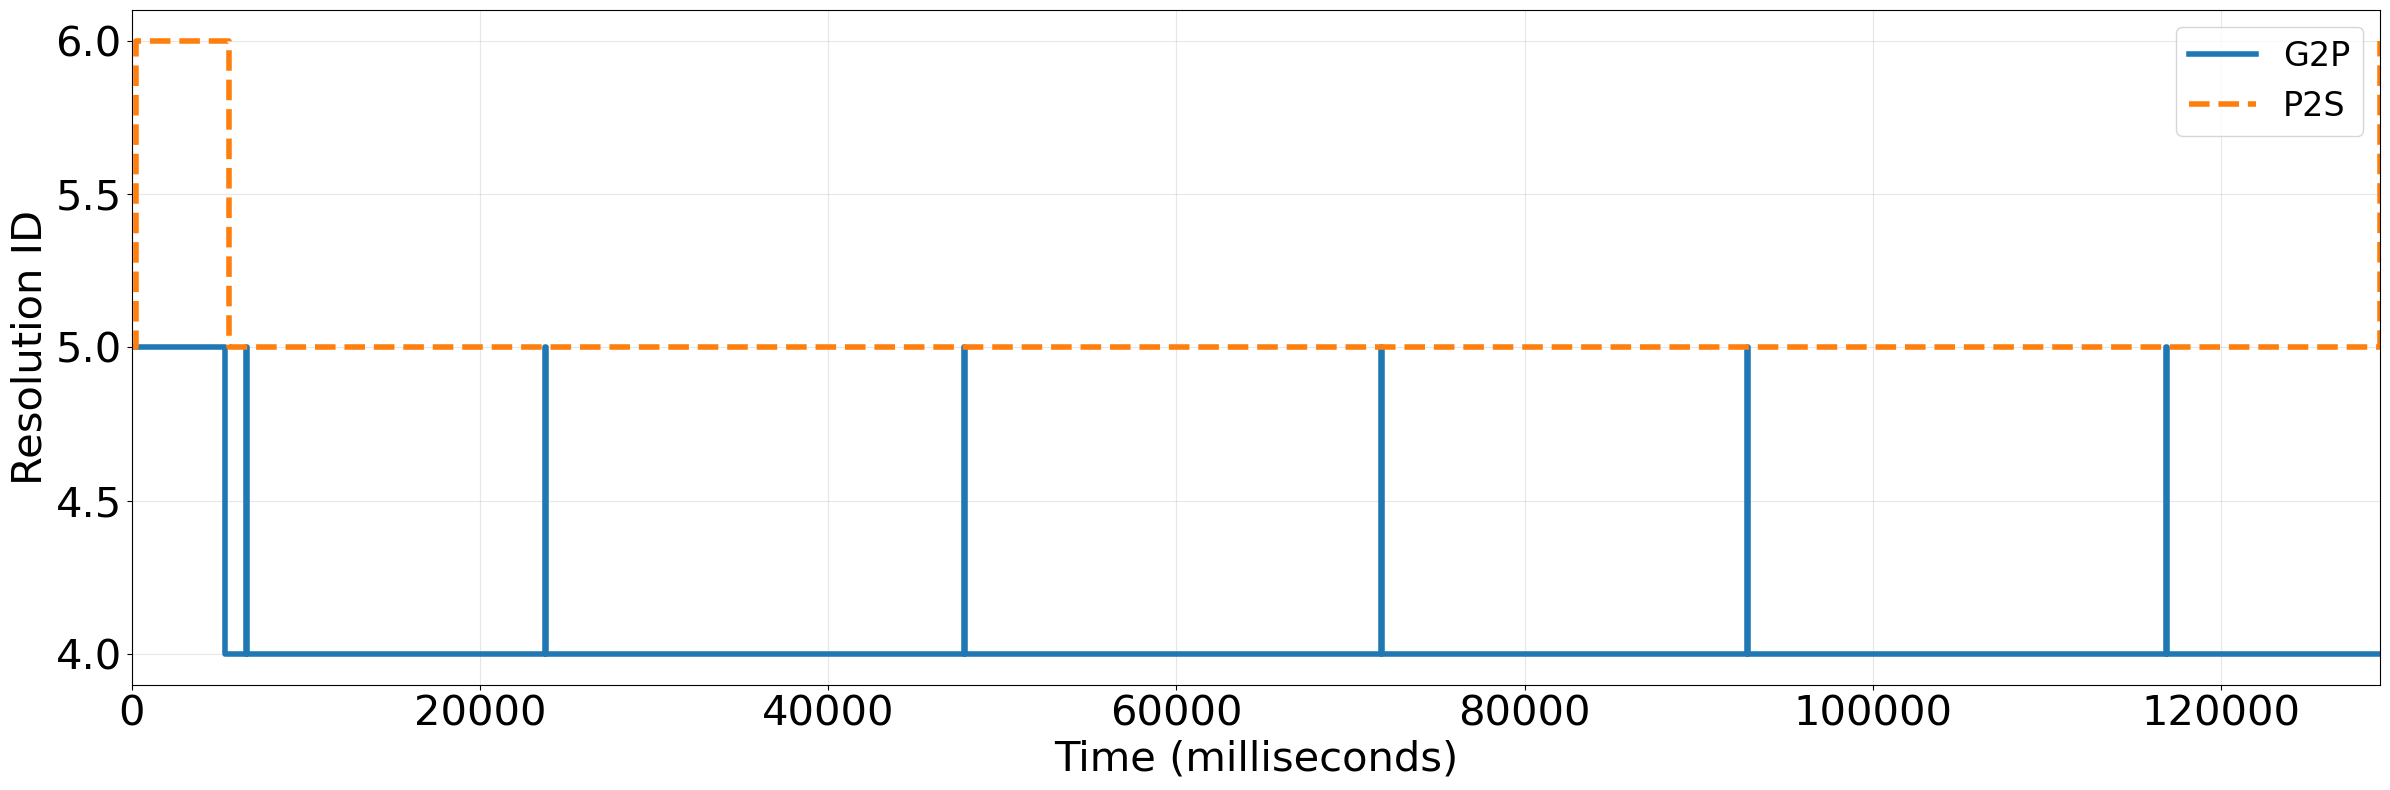

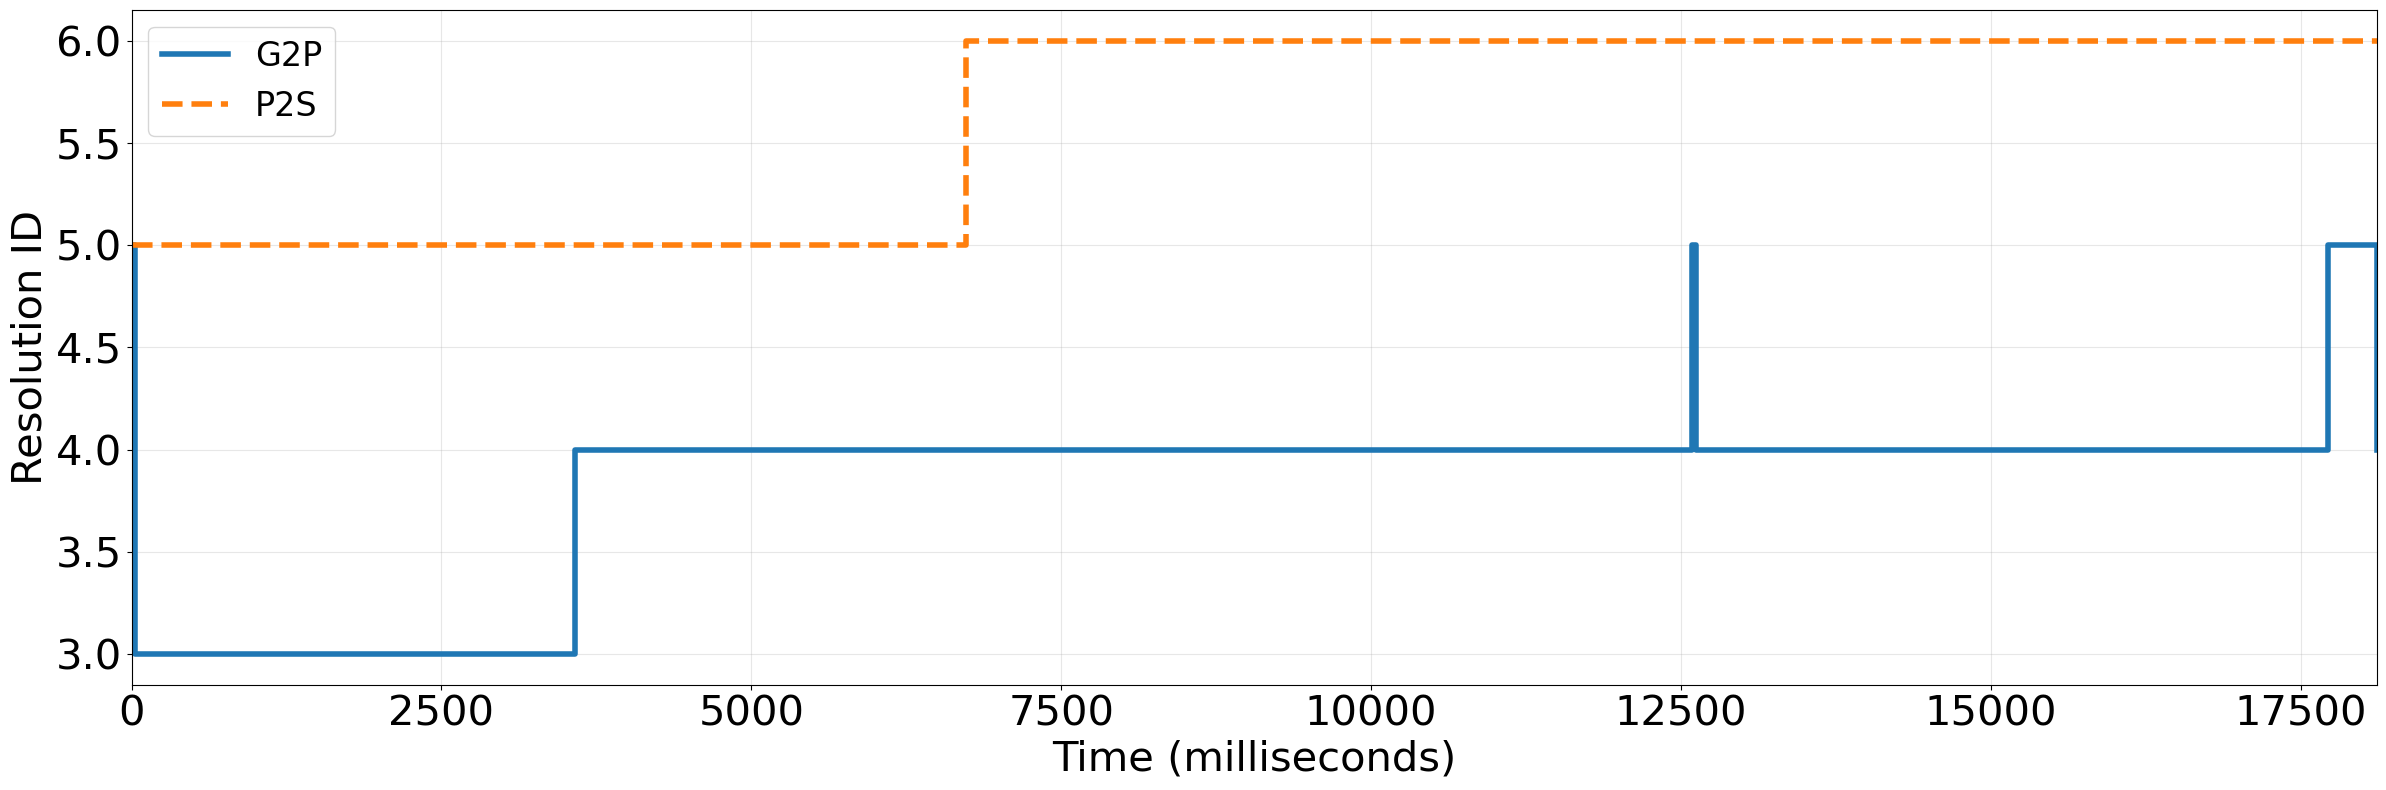

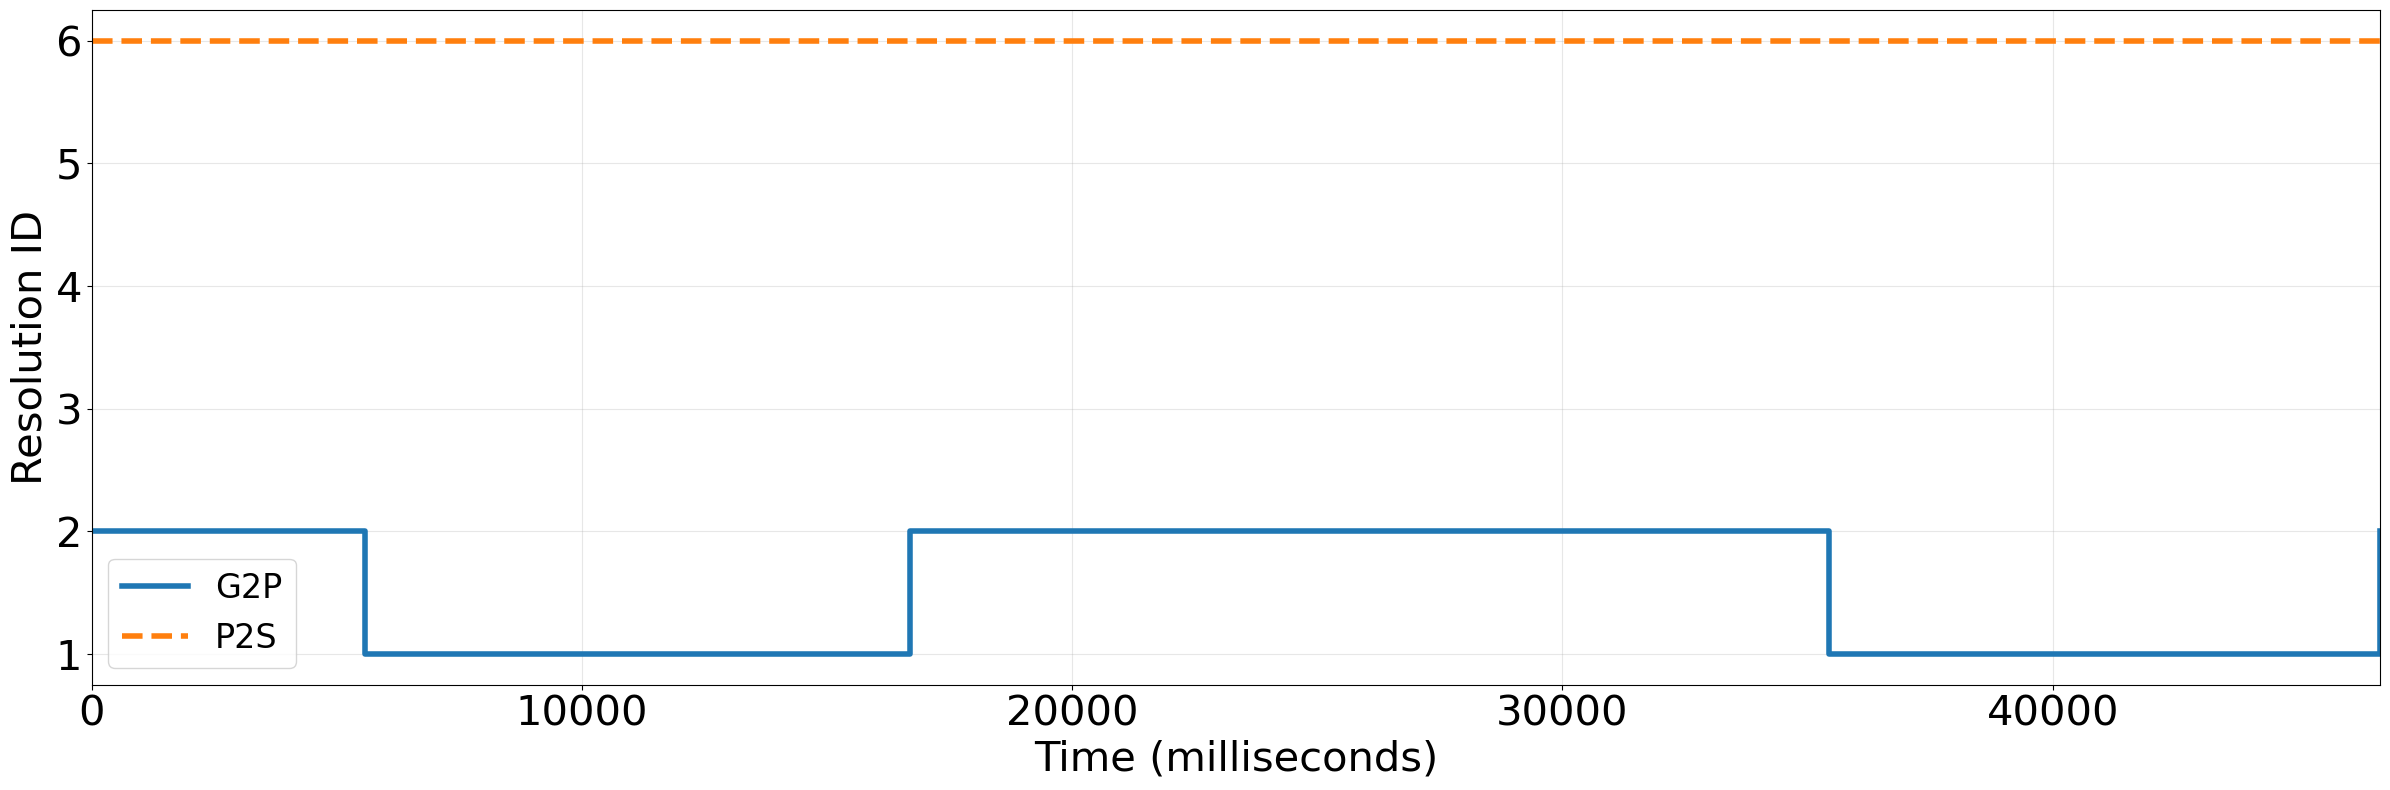

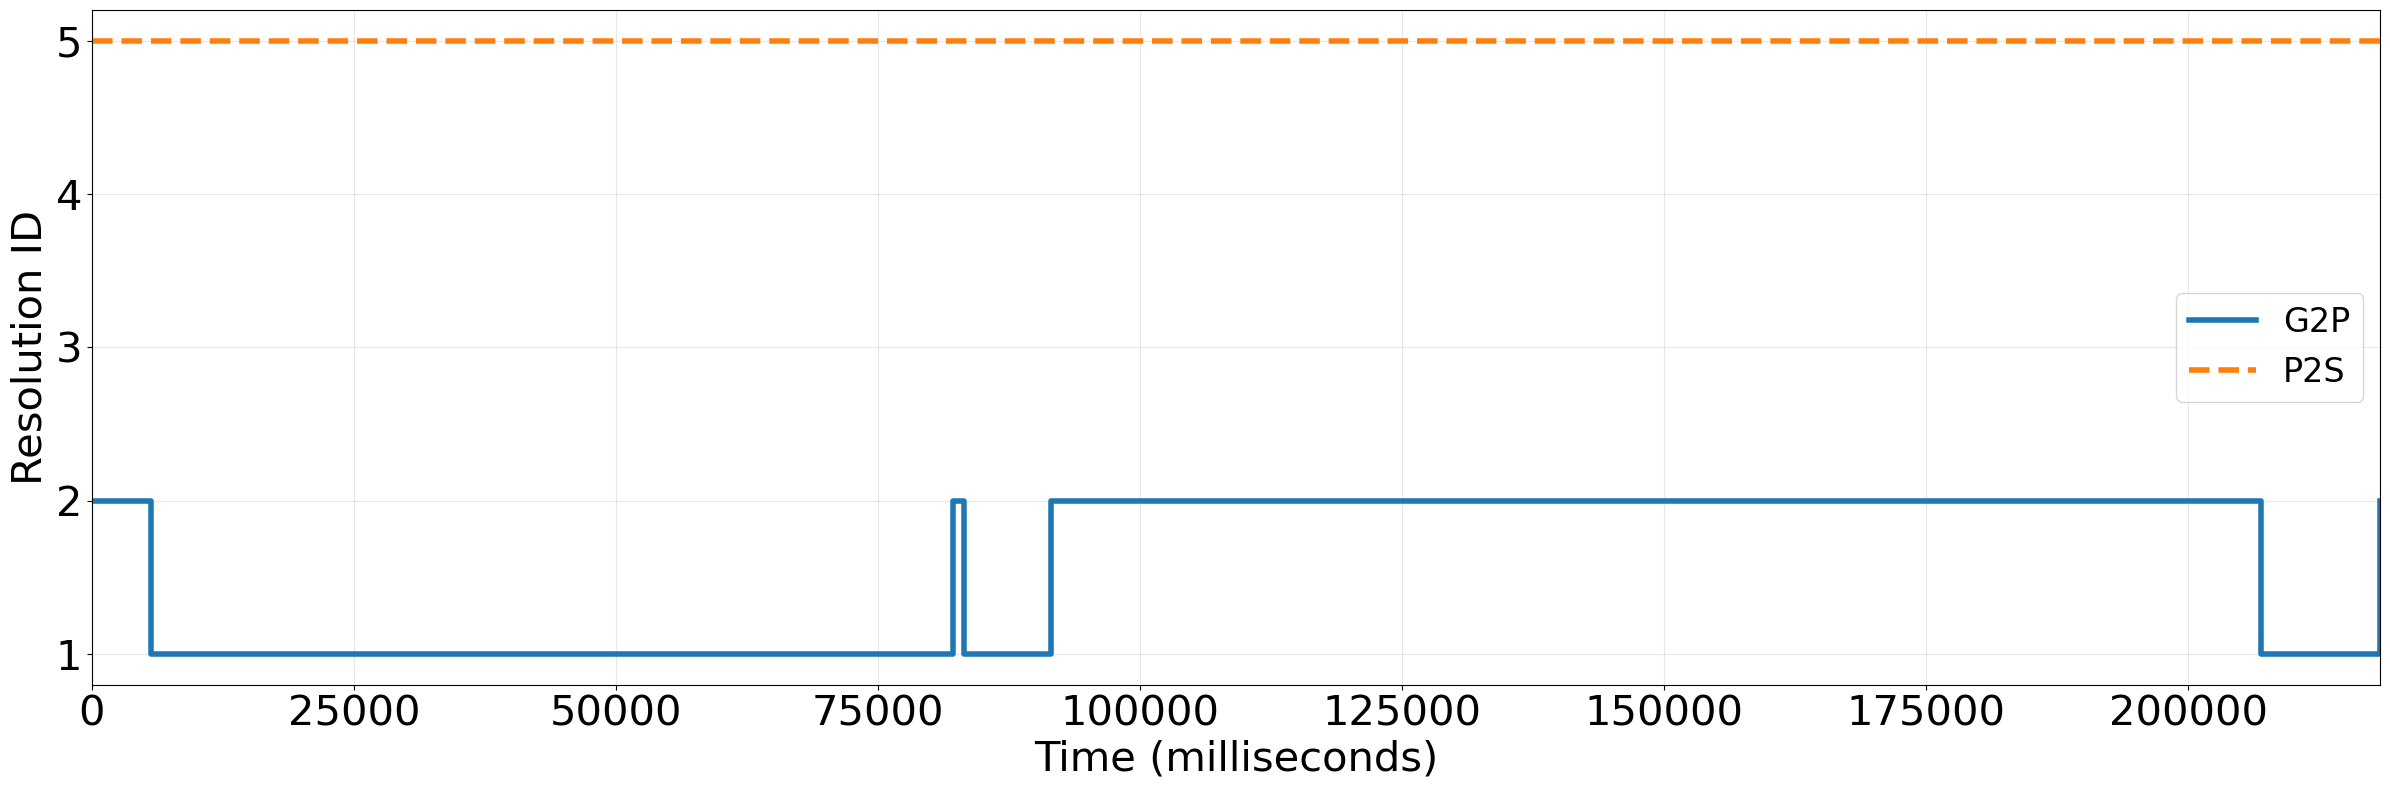

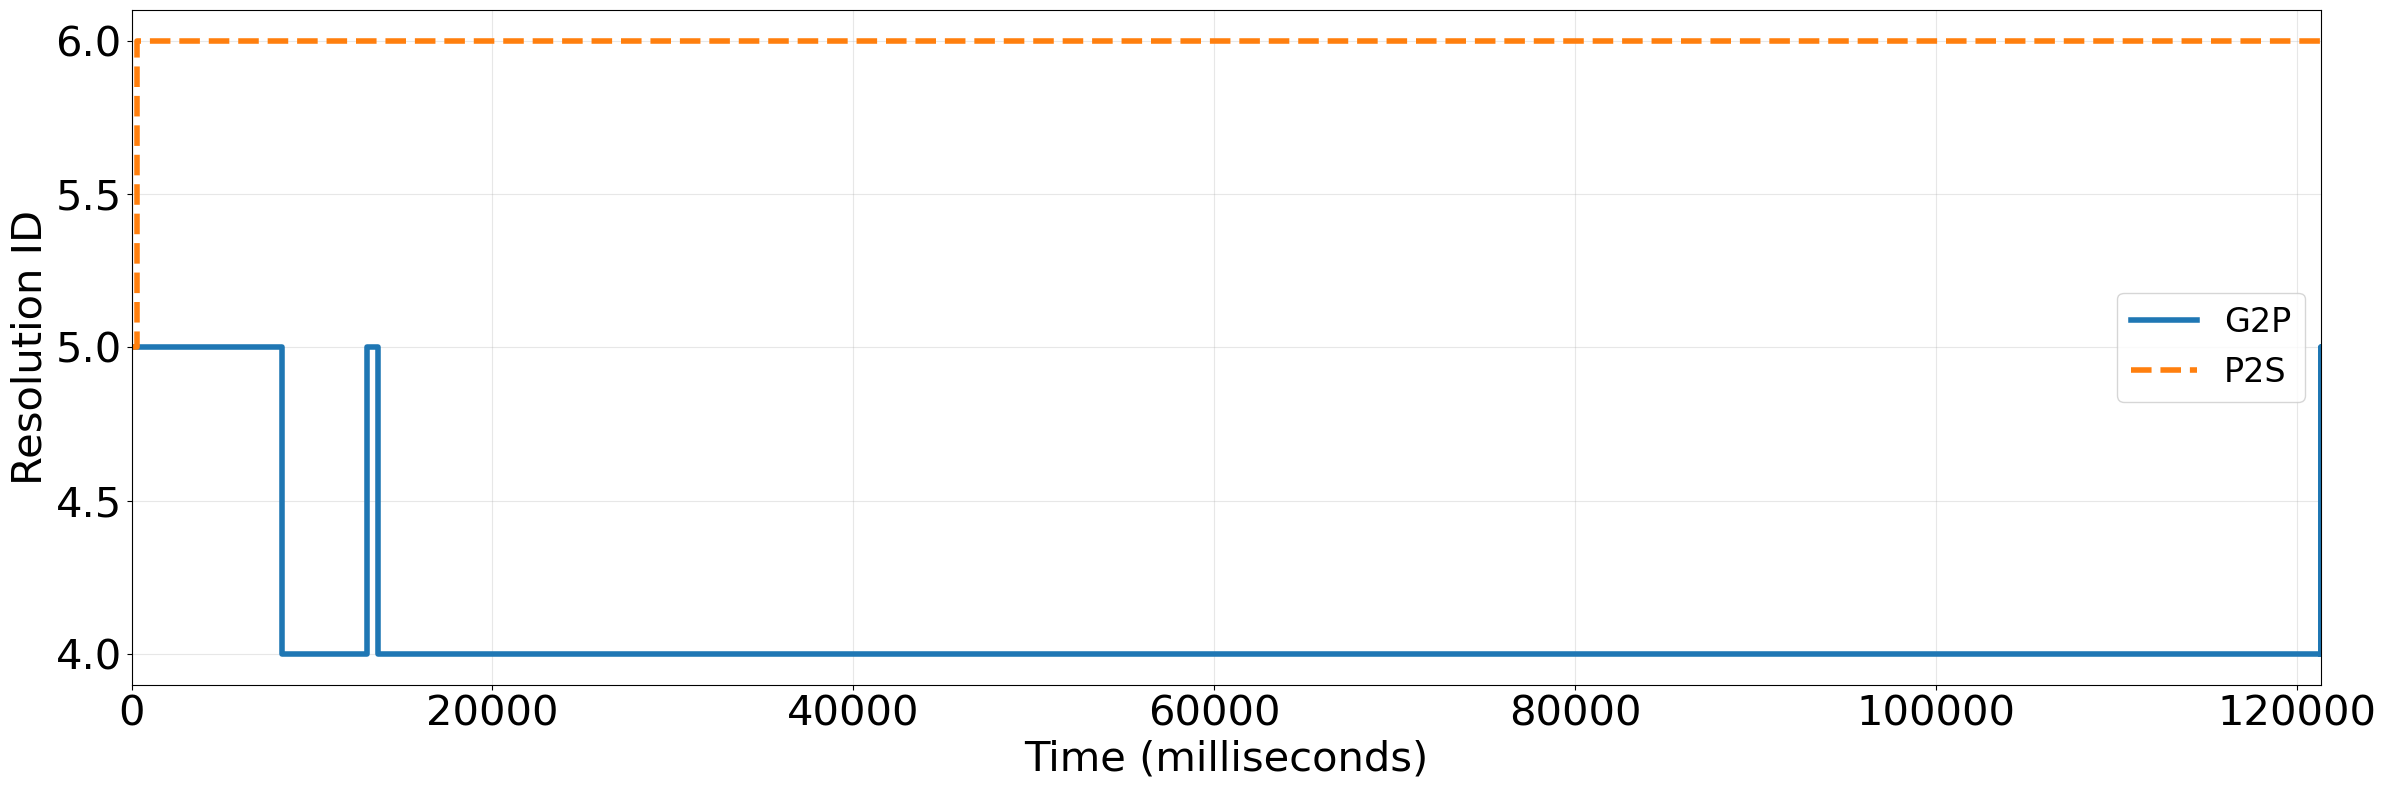

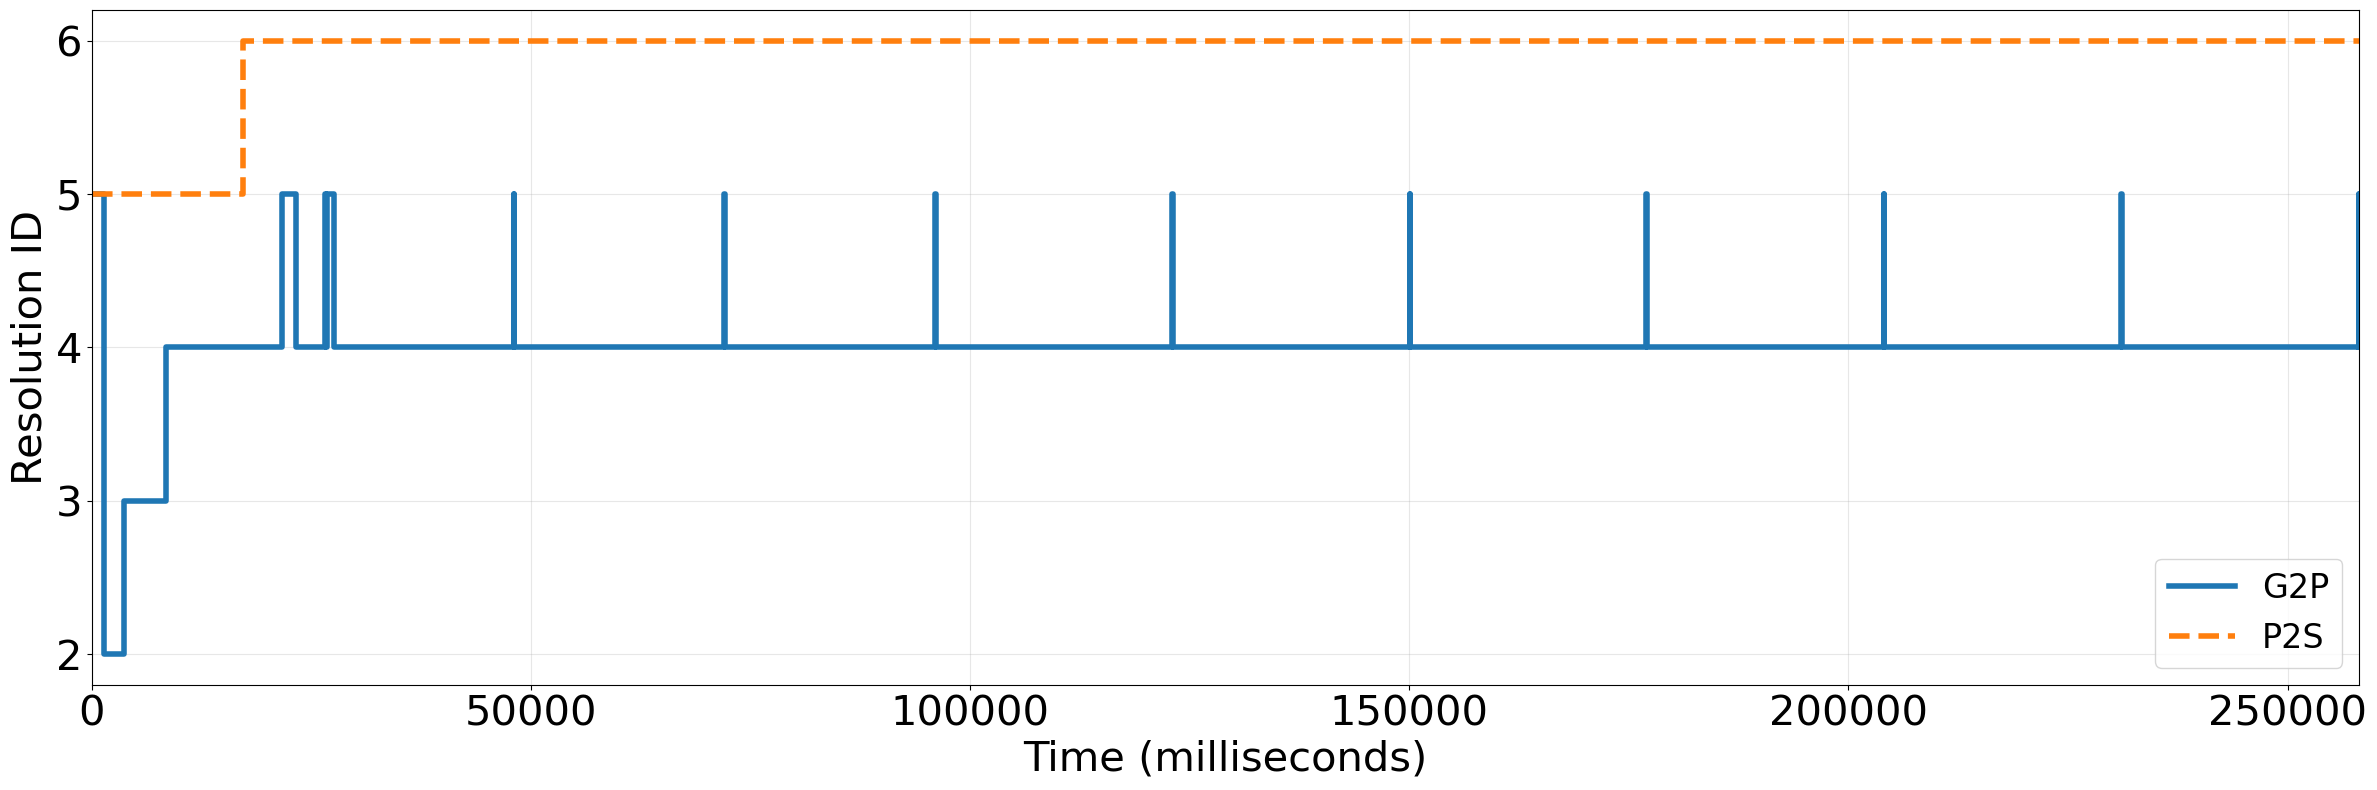

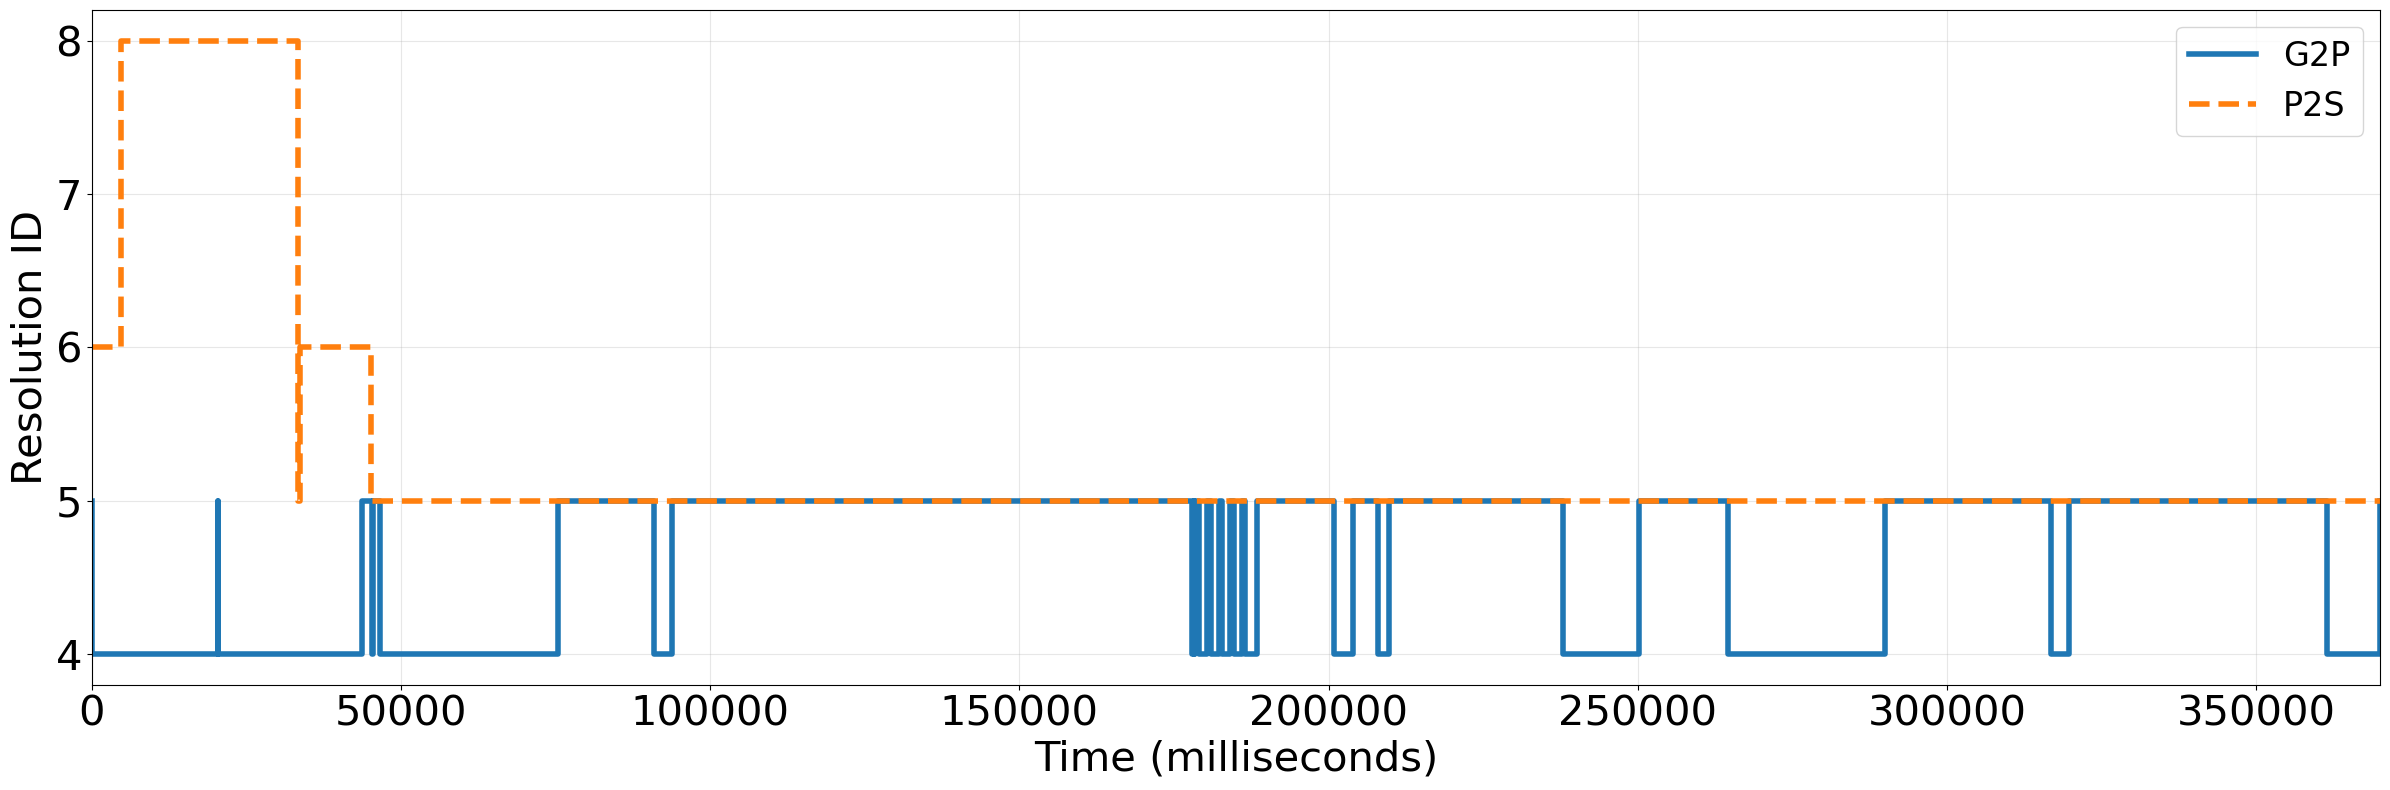

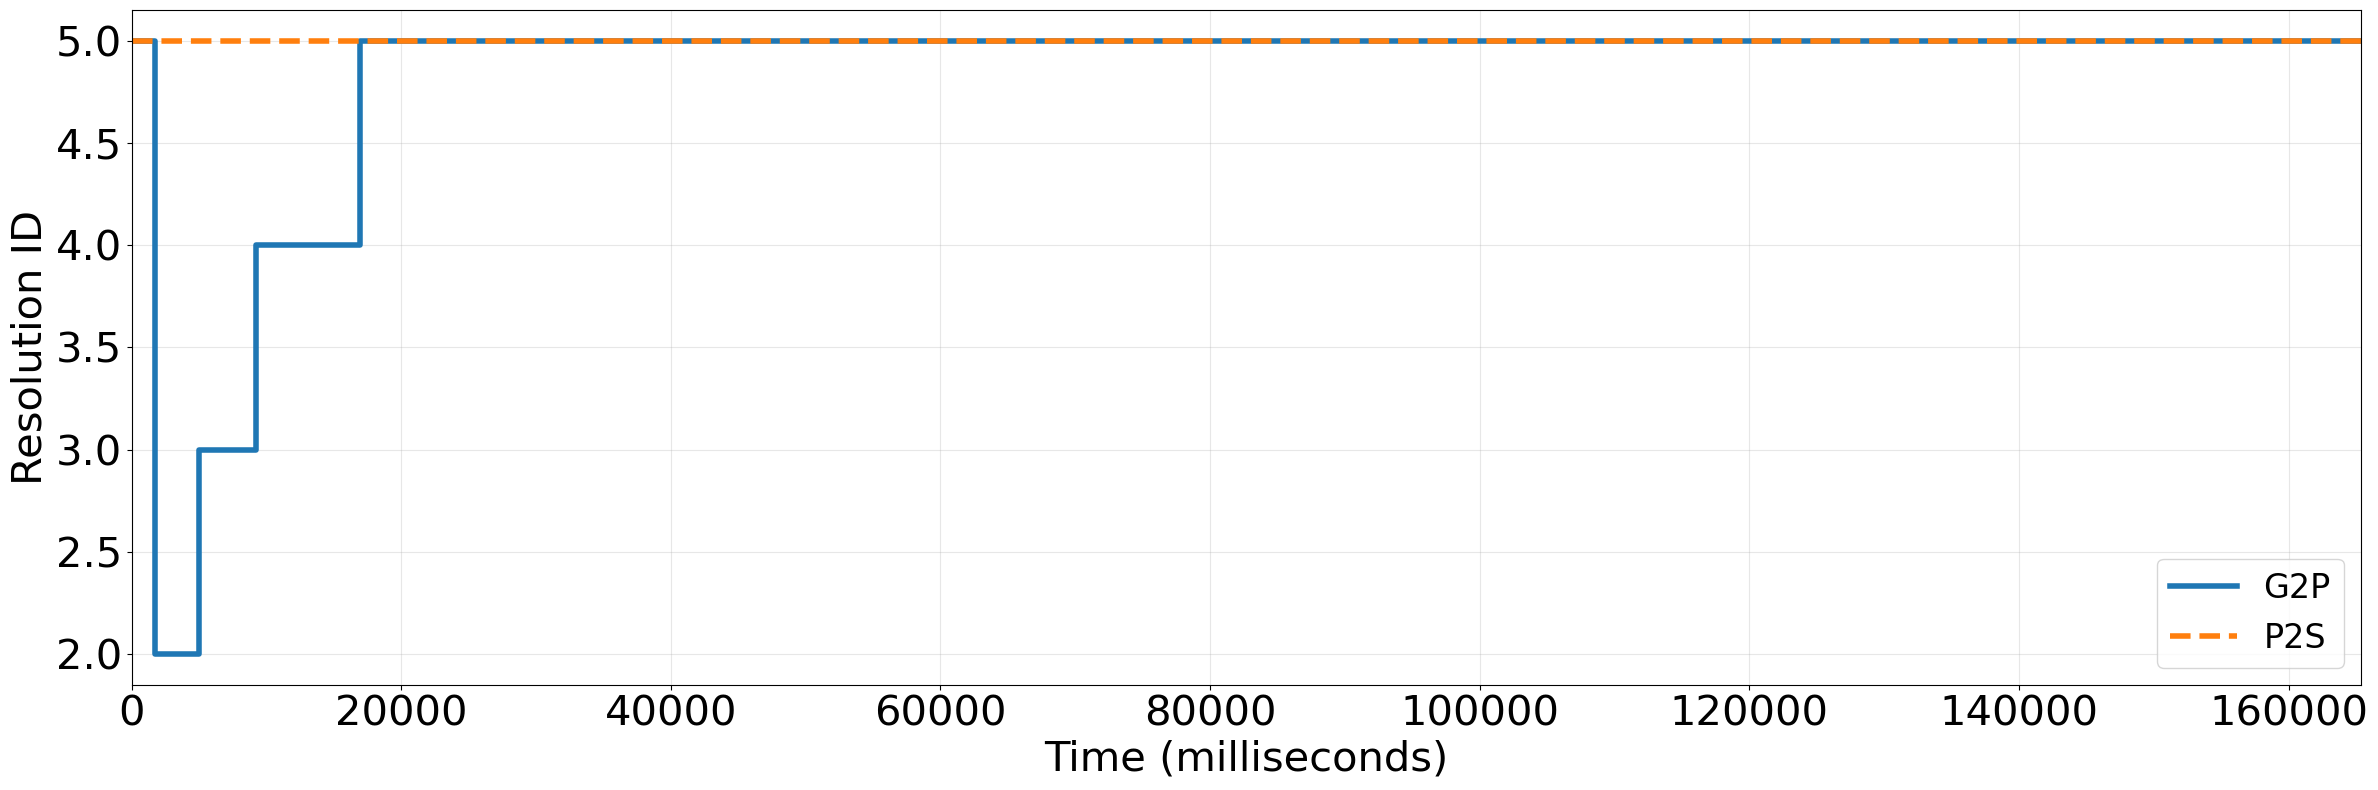

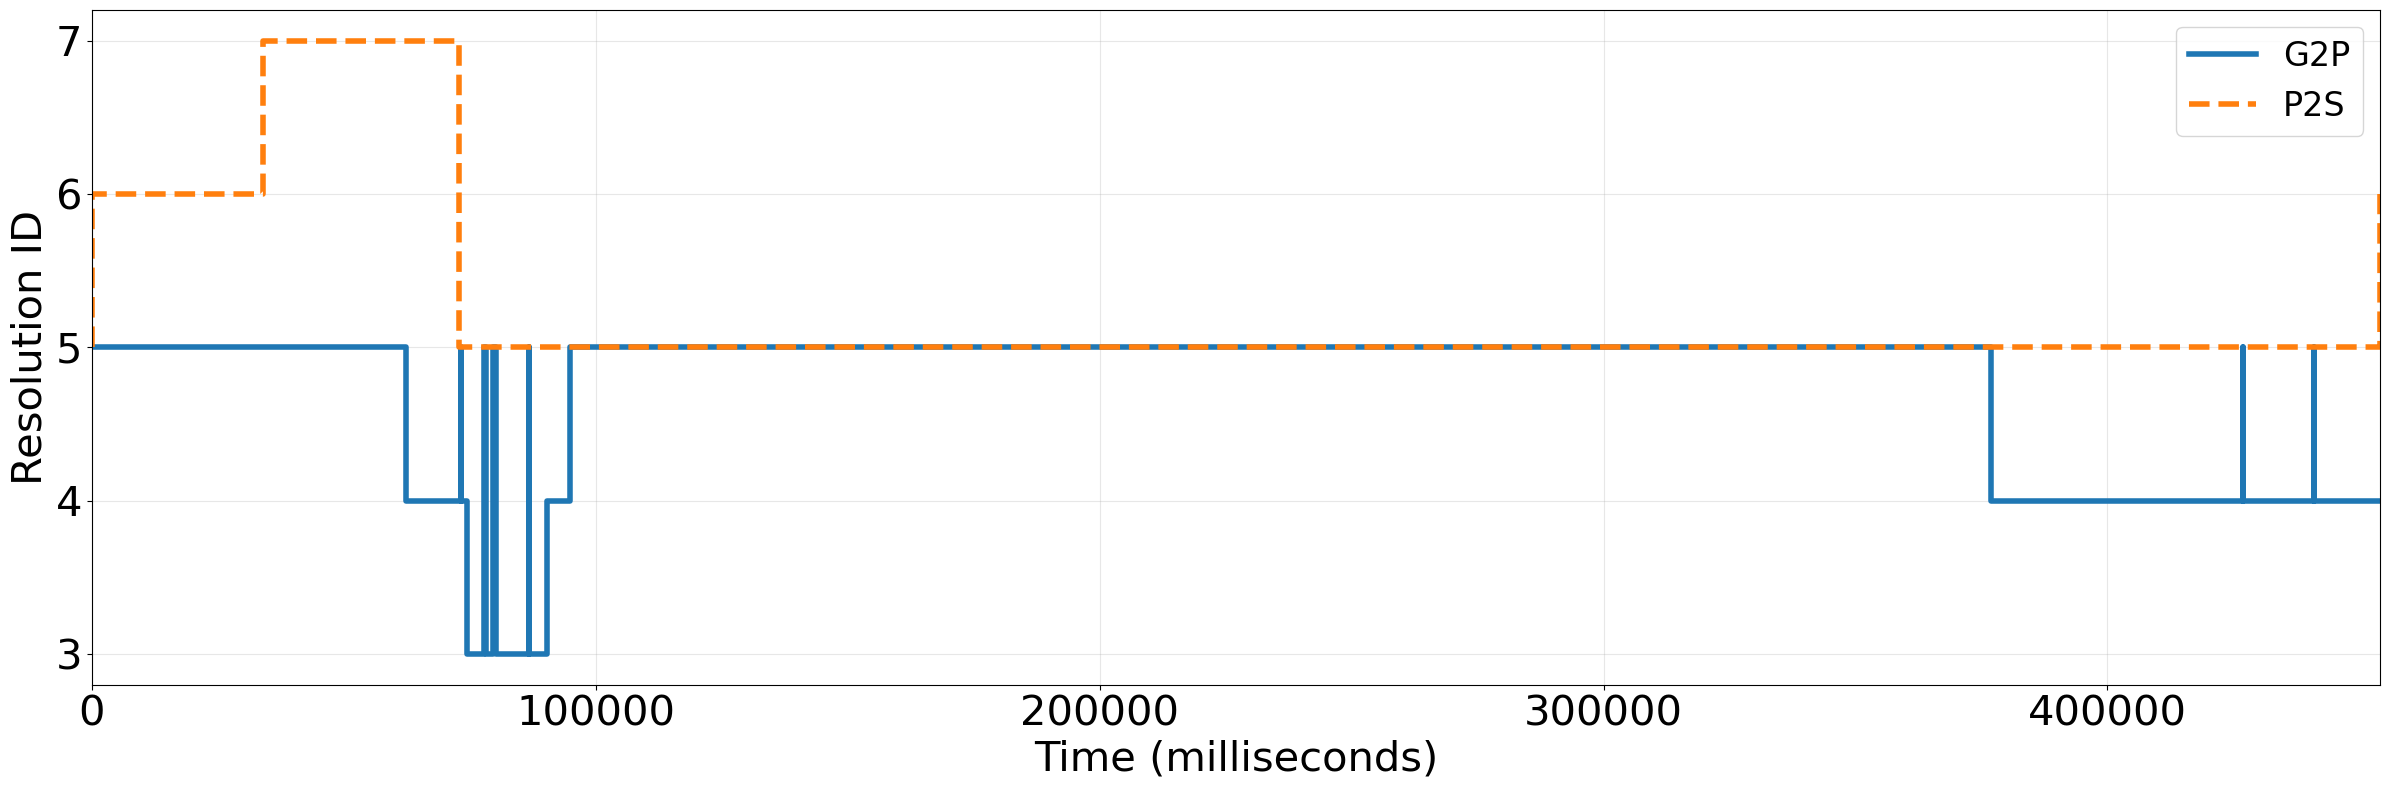

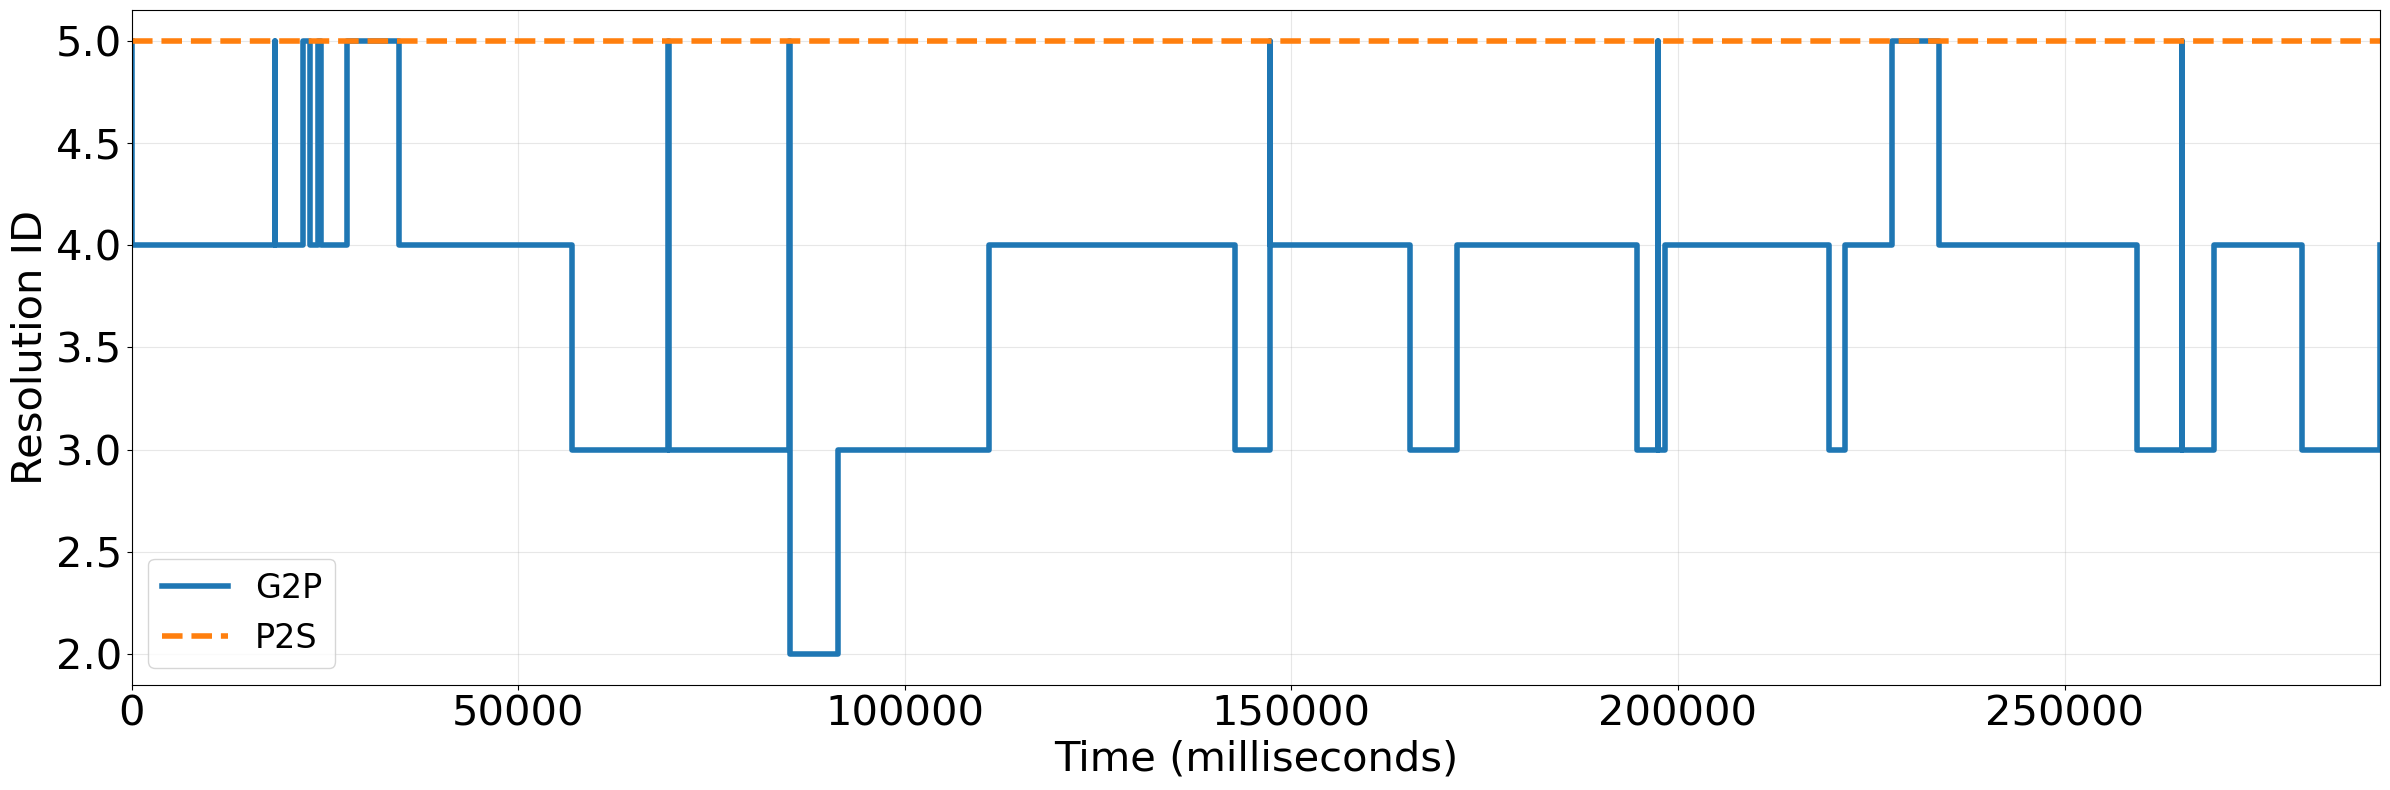

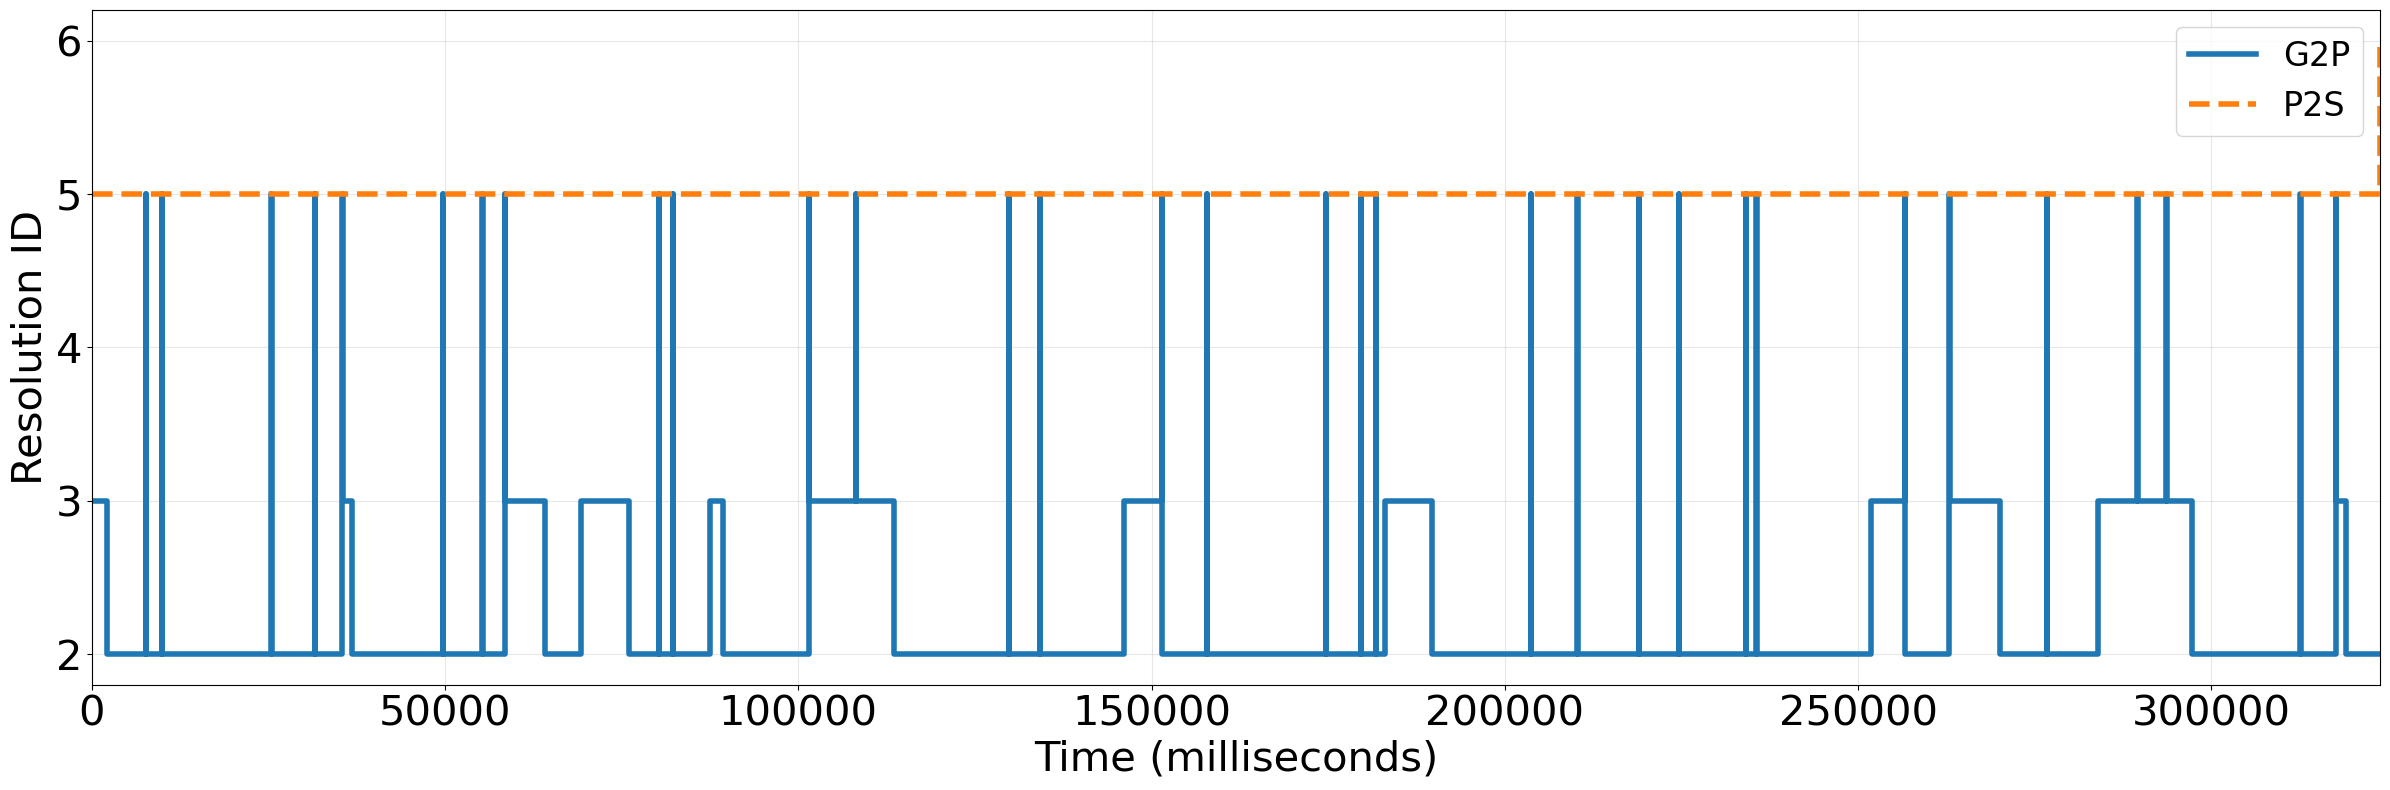

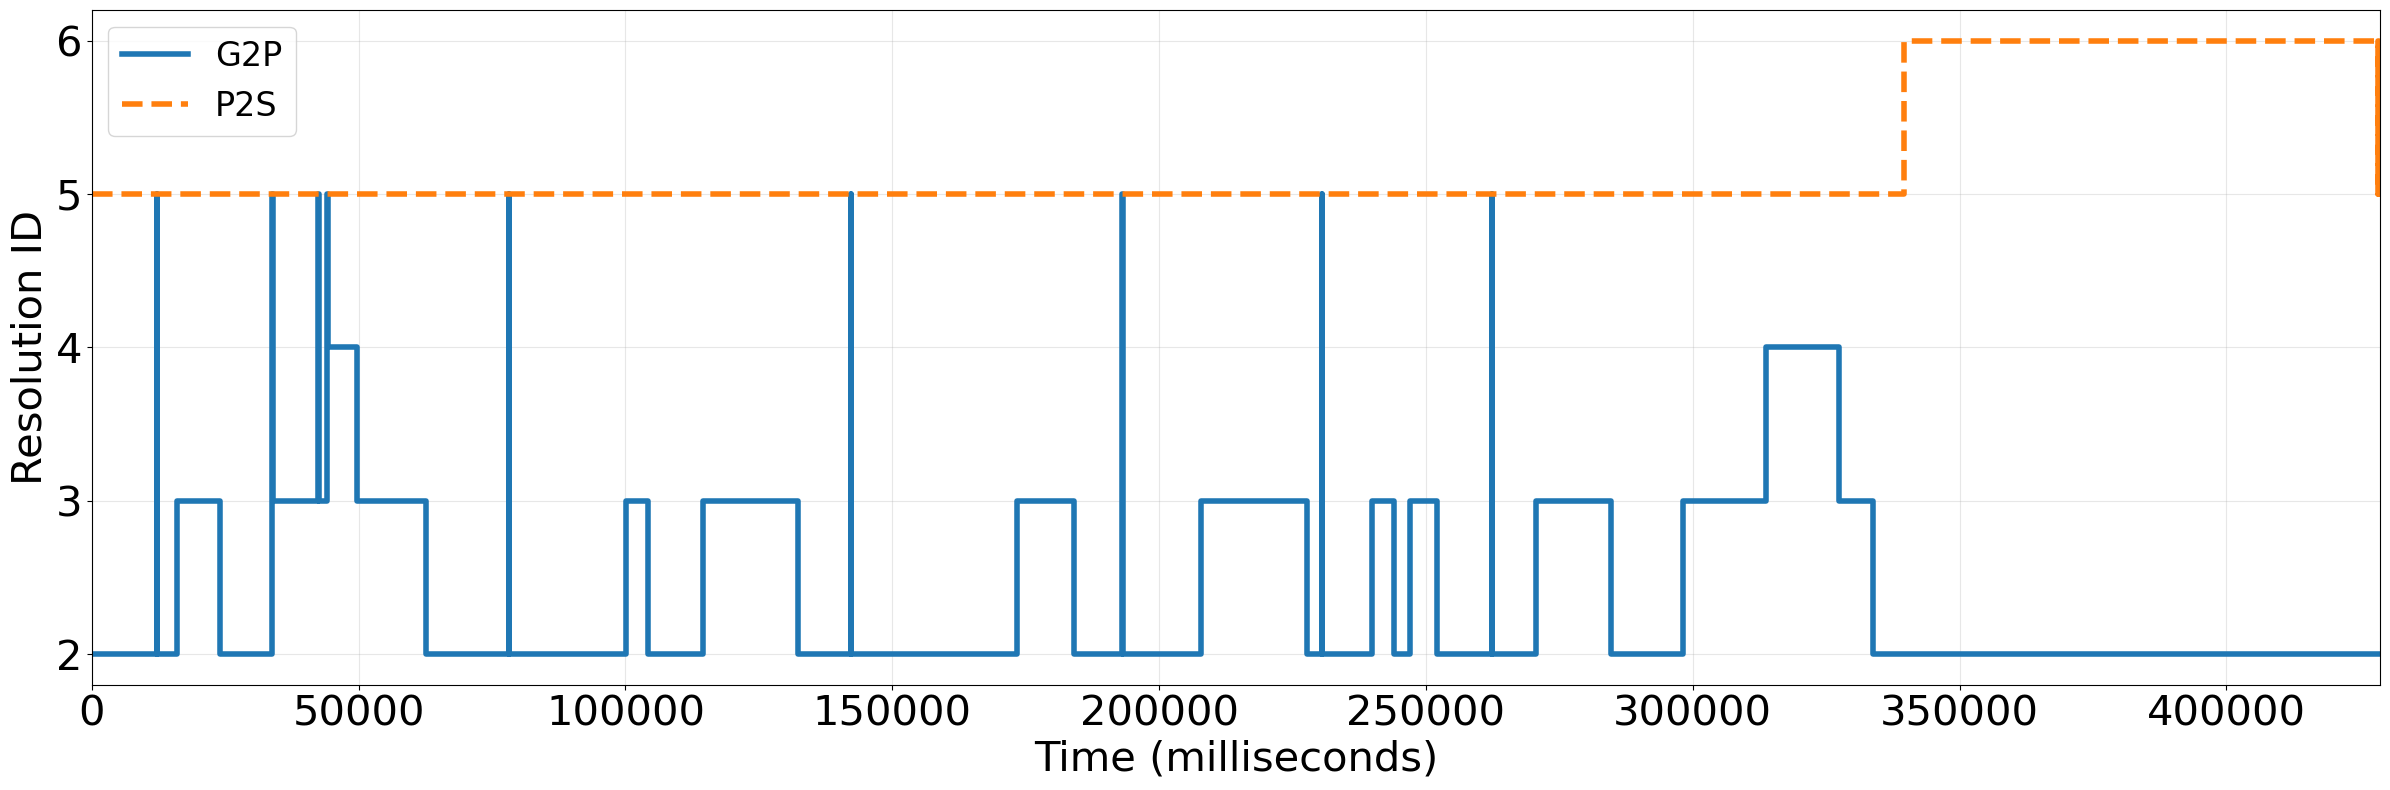

Done.


In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
import os
from datetime import datetime

# Returns lists of (timestamp, resolution) to preserve frequencies and times
def parse_stream_resolutions(log_file):
    """
    Parses a log file to extract and differentiate resolutions for:
    1. Glasses Streamed to Phone (G2P - from CCodecConfig c2 config diff blocks with raw.size for HEVC only)
    2. Phone Streamed to IG/App (P2S - from 'scaler_node.cc' or 'cam[56]_eaf' logs)

    Returns: two lists of (timestamp, resolution) in "WxH" format (g2p_list, p2s_list).
    """
    def parse_timestamp(line):
        match = re.match(r'(\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})', line)
        if match:
            try:
                return datetime.strptime(match.group(1), '%m-%d %H:%M:%S.%f')
            except ValueError:
                return None
        return None

    try:
        with open(log_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File not found at {log_file}")
        return [], []
    except Exception as e:
        print(f"Error reading file {log_file}: {e}")
        return [], []

    # 1. Glasses to Phone (G2P) - Parse from CCodecConfig c2 config diff blocks, only for HEVC
    g2p_matches = []
    i = 0
    while i < len(lines):
        line = lines[i]
        if re.search(r'c2 config diff is', line, re.IGNORECASE):
            ts = parse_timestamp(line)
            if ts is None:
                i += 1
                continue
            block = line
            i += 1
            while i < len(lines) and re.search(r'D CCodecConfig:\s*c2::u32', lines[i], re.IGNORECASE):
                block += '\n' + lines[i]
                i += 1
            # Skip if this is not a HEVC block: for full configs, check mime; for updates (no mime), proceed
            if 'input.media-type.value' in block:
                if 'video/hevc' not in block:
                    continue
            # Extract raw.size.width and height
            match_w = re.search(r'raw\.size\.width = (\d+)', block)
            match_h = re.search(r'raw\.size\.height = (\d+)', block)
            if match_w and match_h:
                w = match_w.group(1)
                h = match_h.group(1)
                res = f"{min(int(w), int(h))}x{max(int(w), int(h))}"
                g2p_matches.append((ts, res))
        else:
            i += 1

    # 2. Phone to Stream (P2S)
    p2s_matches = []
    for line in lines:
        match = re.search(
            r'(?:scaler_node\.cc.*?resolution:\s*(?P<w1>\d+)x(?P<h1>\d+))|'  # Pattern 1: scaler_node
            r'(?:cam[2356]_eaf.*?res\s*(?P<w2>\d+)x(?P<h2>\d+))',               # Pattern 2: cam2, 3, 5, or 6 eaf
            line, re.IGNORECASE)
        
        if match:
            ts = parse_timestamp(line)
            if ts is None:
                continue
            
            w, h = None, None
            # Check which named group actually matched
            if match.group('w1') and match.group('h1'):
                w = match.group('w1')
                h = match.group('h1')
            elif match.group('w2') and match.group('h2'):
                w = match.group('w2')
                h = match.group('h2')
            else:
                continue # No valid group was captured

            # Normalize resolution string to min_dim x max_dim
            res = f"{min(int(w), int(h))}x{max(int(w), int(h))}"
            p2s_matches.append((ts, res))

    return g2p_matches, p2s_matches


def create_resolution_maps(all_resolutions):

    unique_resolutions = set(all_resolutions)

    if not unique_resolutions:
        return {}, {}

    width_groups = defaultdict(list)

    for res in unique_resolutions:

        try:
            width, height = map(int, res.split('x'))
            if width == 2448 and height == 3440:
                continue

            if height not in width_groups[width]:
                width_groups[width].append(height)
        except ValueError:
            continue

    sorted_widths = sorted(width_groups.keys())

    forward_map = {}
    reverse_map = {}
    mapping_id = 1

    for width in sorted_widths:
        heights = sorted(width_groups[width])
        group_key = f"{width}x{heights}"

        forward_map[mapping_id] = group_key
        for height in heights:
            reverse_map[f"{width}x{height}"] = mapping_id
        mapping_id += 1

    return forward_map, reverse_map


def compute_mapping_id_frequencies(resolutions_list, reverse_mapping):
    """
    Compute frequency counts per mapping ID.
    'resolutions_list' is expected to be a list, potentially with duplicates.
    """
    res_counter = Counter(resolutions_list)
    id_frequencies = defaultdict(int)
    excluded_res = "2448x3440"

    for res, count in res_counter.items():
        if res == excluded_res:
            continue
        map_id = reverse_mapping.get(res, None)
        if map_id is not None:
            id_frequencies[map_id] += count

    return dict(id_frequencies)

def compute_durations(ts, ids, min_ts, max_ts):
    if not ts:
        return {}

    t_rel = [((t - min_ts).total_seconds() * 1000) for t in ts]
    max_t_rel = ((max_ts - min_ts).total_seconds() * 1000)

    if t_rel[0] > 0:
        t_rel = [0.0] + t_rel
        ids = [ids[0]] + ids

    if t_rel[-1] < max_t_rel:
        t_rel = t_rel + [max_t_rel]
        ids = ids + [ids[-1]]

    durations = defaultdict(float)
    for i in range(len(t_rel) - 1):
        dur = t_rel[i+1] - t_rel[i]
        durations[ids[i]] += dur

    return durations

def plot_timeline(g2p_list, p2s_list, save_label, reverse_map, save_path=None):
    """
    Plot the resolution ID changes over time for glasses-to-phone (G2P) and phone-to-stream (P2S)
    on the same axes, using time in milliseconds on the x-axis and Mapping IDs on the y-axis.
    Uses step plots to visualize the durations each resolution was active.
    """
    fig, ax = plt.subplots(figsize=(24, 8)) 
    # Filter and sort G2P
    g2p_valid = [(ts, res) for ts, res in g2p_list if res in reverse_map]
    if g2p_valid:
        g2p_valid.sort(key=lambda x: x[0])
        g2p_ts = [item[0] for item in g2p_valid]
        g2p_res = [item[1] for item in g2p_valid]
        g2p_ids = [reverse_map[res] for res in g2p_res]
    else:
        g2p_ts = []
        g2p_ids = []

    # Filter and sort P2S
    p2s_valid = [(ts, res) for ts, res in p2s_list if res in reverse_map]
    if p2s_valid:
        p2s_valid.sort(key=lambda x: x[0])
        p2s_ts = [item[0] for item in p2s_valid]
        p2s_res = [item[1] for item in p2s_valid]
        p2s_ids = [reverse_map[res] for res in p2s_res]
    else:
        p2s_ts = []
        p2s_ids = []

    all_ts = g2p_ts + p2s_ts
    if not all_ts:
        plt.close()
        return

    min_ts = min(all_ts)
    plotted = False

    # Compute max_t_rel
    all_t_rel = [((ts - min_ts).total_seconds() * 1000) for ts in all_ts]
    max_t_rel = max(all_t_rel) if all_t_rel else 0.0

    # G2P (Glasses-to-Phone)
    if g2p_ts:
        g2p_t_rel = [((ts - min_ts).total_seconds() * 1000) for ts in g2p_ts]  # Convert to milliseconds
        
        # Start at 0 if not already
        if g2p_t_rel[0] > 0:
            g2p_t_rel.insert(0, 0.0)
            g2p_ids.insert(0, g2p_ids[0])
        
        # Extend to the end with a small delta for the last horizontal segment
        if g2p_t_rel[-1] < max_t_rel:
            g2p_t_rel.append(max_t_rel)
            g2p_ids.append(g2p_ids[-1])
        delta = 1.0  # Small delta in ms
        g2p_t_rel.append(max_t_rel + delta)
        g2p_ids.append(g2p_ids[-1])
        
        ax.step(g2p_t_rel, g2p_ids, where='post', label='G2P', linewidth=4, linestyle='-')
        plotted = True

    # P2S (Phone-to-Stream)
    if p2s_ts:
        p2s_t_rel = [((ts - min_ts).total_seconds() * 1000) for ts in p2s_ts]  # Convert to milliseconds
        
        # Start at 0 if not already
        if p2s_t_rel[0] > 0:
            p2s_t_rel.insert(0, 0.0)
            p2s_ids.insert(0, p2s_ids[0])
        
        # Extend to the end with a small delta for the last horizontal segment
        if p2s_t_rel[-1] < max_t_rel:
            p2s_t_rel.append(max_t_rel)
            p2s_ids.append(p2s_ids[-1])
        delta = 1.0  # Small delta in ms
        p2s_t_rel.append(max_t_rel + delta)
        p2s_ids.append(p2s_ids[-1])
        
        ax.step(p2s_t_rel, p2s_ids, where='post', label='P2S', linewidth=4, linestyle='--')
        plotted = True

    if not plotted:
        plt.close()
        return
    else:
        ax.set_xlabel('Time (milliseconds)', fontsize=30)
        ax.set_ylabel('Resolution ID', fontsize=30)
        ax.tick_params(axis='both', labelsize=30)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=24)
        ax.set_xlim(0, max_t_rel)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

def plot_cdf(g2p_list, p2s_list, save_label, reverse_map, save_path=None):
    g2p_valid = [(ts, res) for ts, res in g2p_list if res in reverse_map]
    if g2p_valid:
        g2p_valid.sort(key=lambda x: x[0])
        g2p_ts = [item[0] for item in g2p_valid]
        g2p_ids = [reverse_map[res] for res in [item[1] for item in g2p_valid]]
    else:
        g2p_ts = []
        g2p_ids = []

    # Filter and sort P2S
    p2s_valid = [(ts, res) for ts, res in p2s_list if res in reverse_map]
    if p2s_valid:
        p2s_valid.sort(key=lambda x: x[0])
        p2s_ts = [item[0] for item in p2s_valid]
        p2s_ids = [reverse_map[res] for res in [item[1] for item in p2s_valid]]
    else:
        p2s_ts = []
        p2s_ids = []

    all_ts = g2p_ts + p2s_ts
    if not all_ts:
        return

    min_ts = min(all_ts)
    max_ts = max(all_ts)

    g2p_durs = compute_durations(g2p_ts, g2p_ids, min_ts, max_ts)
    p2s_durs = compute_durations(p2s_ts, p2s_ids, min_ts, max_ts)

    max_id = max(reverse_map.values()) if reverse_map else 0

    g_cum = None
    if g2p_durs:
        g_times = [g2p_durs.get(i, 0.0) for i in range(1, max_id + 1)]
        g_total = sum(g_times)
        if g_total > 0:
            g_cum = np.cumsum(g_times) / g_total

    p_cum = None
    if p2s_durs:
        p_times = [p2s_durs.get(i, 0.0) for i in range(1, max_id + 1)]
        p_total = sum(p_times)
        if p_total > 0:
            p_cum = np.cumsum(p_times) / p_total

    if g_cum is None and p_cum is None:
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(1, max_id + 1)
    plotted = False

    if g_cum is not None:
        ax.step(x, g_cum, where='post', label='G2P', linewidth=4)
        plotted = True

    if p_cum is not None:
        ax.step(x, p_cum, where='post', label='P2S', linewidth=4, linestyle='--')
        plotted = True

    if not plotted:
        plt.close()
        return
    else:
        ax.set_xlabel('Resolution', fontsize=55)
        ax.set_ylabel('CDF', fontsize=55)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='both', labelsize=55)
        ax.set_xticks(x)
        ax.grid(True, alpha=0.7)
        ax.legend(fontsize=40, loc='upper left')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

def main():
    """
    Main function to process files, create mappings, and plot resolution ID changes over time.
    """
    log_files = [
        "Test01_logcat_WD_RB_insta_Live.txt",
        "Test01_logcat_BT_RB_insta_Live.txt",
        "Test01_logcat_WD_RB_Messenger.txt",
        "Test01_logcat_WD_RB_Whatsapp.txt",
        "Test01_logcat_BT_RB_FB_Live.txt",
        "Test01_logcat_WD_RB_FB_Live.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_8.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_8m.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_20.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_20.txt",
        "Test01_logcat_WD_RB_insta_Live_Distance_30.txt",
        "Test01_logcat_BT_RB_insta_Live_Distance_30.txt"
    ]

    file_results = {}
    all_resolutions_with_duplicates = []
    excluded_res = "2448x3440"

    for log_file in log_files:
        # Simple check to skip missing files
        if not os.path.exists(log_file):
            print(f"Skipping missing file: {log_file}")
            continue
            
        print(f"Parsing {log_file}...")
        g2p_list, p2s_list = parse_stream_resolutions(log_file)

        file_results[log_file] = {
            'g2p': g2p_list,
            'p2s': p2s_list
        }

        all_resolutions_with_duplicates.extend([res for _, res in g2p_list])
        all_resolutions_with_duplicates.extend([res for _, res in p2s_list])

    print("All files parsed.")

    mapping, reverse_mapping = create_resolution_maps(set(all_resolutions_with_duplicates))

    print("--- Global Resolution Mapping ---")
    print("ID is assigned based on increasing width.\n")
    if not mapping:
        print("No resolution data found to create a map.")
    else:
        # Print mapping with ID first for clarity with the plot
        for map_id, res_group in sorted(mapping.items()):
            print(f"ID: {map_id} -> Group: {res_group}")
    print("\n" + "="*40 + "\n")

    # Check if any files were actually processed
    if not file_results:
        print("No log files were found or processed. Exiting.")
        return

    for log_file in file_results.keys(): # Iterate over processed files
        parts = log_file.split('_')
        connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
        app_match = re.search(r'RB_(.*?)\.txt', log_file)
        app = app_match.group(1) if app_match else 'unknown'

        print(f"--- Detailed Results for {app.capitalize()} ({connection}): {log_file} ---")

        g2p_results_list = file_results[log_file]['g2p']
        p2s_results_list = file_results[log_file]['p2s']

        g2p_res_only = [res for _, res in g2p_results_list]
        p2s_res_only = [res for _, res in p2s_results_list]

        if g2p_res_only:
            g2p_counts = Counter(r for r in g2p_res_only)
            if g2p_counts:
                print("\n  Glasses to Phone (G2P) Resolutions (from CCodecConfig):")
                for resolution, count in sorted(g2p_counts.items()):
                    map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
                    print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
            else:
                print("\n  No non-excluded Glasses to Phone (G2P) Resolutions found.")
        else:
            print("\n  No Glasses to Phone (G2P) Resolutions found in this file.")

        if p2s_res_only:
            p2s_counts = Counter(r for r in p2s_res_only)
            if p2s_counts:
                print(f"\n  Phone to Stream (P2S) Resolutions (from scaler_node/cam_eaf):") # Updated text
                for resolution, count in sorted(p2s_counts.items()):
                    map_id = reverse_mapping.get(resolution, "N/A (Excluded or Not Found)")
                    print(f" - Resolution: {resolution}, Frequency: {count}, Mapping ID: {map_id}")
            else:
                print("\n  No non-excluded Phone to Stream (P2S) Resolutions found.")
        else:
            print(f"\n  No Phone to Stream (P2S) Resolutions found in this file.")

        print("\n" + "="*40 + "\n")

    print("Generating plots...")
    os.makedirs("./Figures", exist_ok=True)
    for log_file in file_results.keys(): # Iterate over processed files
        parts = log_file.split('_')
        connection = 'WD' if 'WD' in parts else ('BT' if 'BT' in parts else '_')
        app_match = re.search(r'RB_(.*?)\.txt', log_file)
        app = app_match.group(1) if app_match else 'unknown'

        g2p_list = file_results[log_file]['g2p']
        p2s_list = file_results[log_file]['p2s']

        save_label = f"{connection}_{app}"

        timeline_save_path = None
        cdf_save_path = f"./Figures/{save_label}_cdf.png"
        
        plot_timeline(g2p_list, p2s_list, save_label, reverse_mapping, save_path=timeline_save_path)
        plot_cdf(g2p_list, p2s_list, save_label, reverse_mapping, save_path=cdf_save_path)

    print("Done.")

if __name__ == "__main__":
    main()